# CNN Assignment

In [2]:
# general
import os
import string
import random
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from collections import Counter, defaultdict

# dataset
from datasets import load_dataset

# plots
import seaborn as sns
import matplotlib.pyplot as plt

# torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

# nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

# pretrained model
import gensim.downloader as api

# tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# interpolation
from scipy.interpolate import interp1d

# sklearn
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import auc, precision_recall_curve, classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cpu


## **1. Dataset**

- DBpedia 14 (Hugging Face)
    - Contains 560,000 Wikipedia articles
    - Categorized into 14 categories
    - Each article includes:
        - Title: The title of the Wikipedia article.
        - Content: The text content from the Wikipedia article.

- Categories: Company, EducationalInstitution, Artist, Athlete, OfficeHolder, and more.

In [4]:
def load_db():
    dataset = load_dataset("dbpedia_14")
    dp_train = dataset["train"]
    dp_test = dataset["test"]
    categories = dp_train.features['label'].names

     # Print the features to understand the structure
    print("Features:", dp_train.features)
    print("Categories:", categories)
    print()
    print()

    data = []
    for i in range(20):
        label_index = dp_train[i]['label']
        data.append([dp_train[i]['title'], dp_train[i]['content'][:500], categories[label_index]])

    df = pd.DataFrame(data, columns=["Title", "Content", "Category"])

    # Convert DataFrame to scrollable HTML table
    html_table = df.to_html(index=False)

    # Wrap in a div with CSS to make it scrollable
    scrollable_html = f"""
    <div style="width:100%; overflow-x:auto; white-space:nowrap;">
        {html_table}
    </div>
    """
    display(HTML(scrollable_html))

    return dp_train, dp_test

In [5]:
train_data, test_data = load_db()

Features: {'label': ClassLabel(names=['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork'], id=None), 'title': Value(dtype='string', id=None), 'content': Value(dtype='string', id=None)}
Categories: ['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork']




Title,Content,Category
E. D. Abbott Ltd,Abbott of Farnham E D Abbott Limited was a British coachbuilding business based in Farnham Surrey trading under that name from 1929. A major part of their output was under sub-contract to motor vehicle manufacturers. Their business closed in 1972.,Company
Schwan-Stabilo,Schwan-STABILO is a German maker of pens for writing colouring and cosmetics as well as markers and highlighters for office use. It is the world's largest manufacturer of highlighter pens Stabilo Boss.,Company
Q-workshop,Q-workshop is a Polish company located in Poznań that specializes in designand production of polyhedral dice and dice accessories for use in various games (role-playing gamesboard games and tabletop wargames). They also run an online retail store and maintainan active forum community.Q-workshop was established in 2001 by Patryk Strzelewicz – a student from Poznań. Initiallythe company sold its products via online auction services but in 2005 a website and online store wereestablished.,Company
Marvell Software Solutions Israel,Marvell Software Solutions Israel known as RADLAN Computer Communications Limited before 2007 is a wholly owned subsidiary of Marvell Technology Group that specializes in local area network (LAN) technologies.,Company
Bergan Mercy Medical Center,Bergan Mercy Medical Center is a hospital located in Omaha Nebraska. It is part of the Alegent Health System.,Company
The Unsigned Guide,The Unsigned Guide is an online contacts directory and careers guide for the UK music industry. Founded in 2003 and first published as a printed directory The Unsigned Guide became an online only resource in November 2011.,Company
Rest of the world,Within sports and games played at the international competitive level the Rest of the World refers to a team of players from many countries of origin that compete against a single individual or a team from a single group such as a club or country. The team was formed in 1998.,Company
Globoforce,Globoforce is a multinational company co-headquartered in Southborough Massachusetts and Dublin Ireland providing cloud-based (software as a service) human capital management (HCM) software solutions. Its social recognition solutions are designed for employees to recognize and reward each other as incentive for performance and behaviors that are mapped to company values. A private corporation Globoforce is co-headquartered in Southborough Massachusetts and Dublin Ireland.,Company
Rompetrol,The Rompetrol Group N.V. is a Romanian oil company that operates in many countries throughout Europe. The group is active primarily in refining marketing and trading with additional operations in exploration and production and other oil industry services such as drilling EPCM and transportation.,Company
Wave Accounting,Wave is the brand name for a suite of online small business software products. The legal company name is Wave Accounting Inc. Wave is headquartered in the Leslieville neighbourhood in Toronto Canada and is currently being used in 200 countries.The company's first product was a free online accounting software designed for businesses with 1-9 employees.,Company


- Count of samples per category 

In [5]:
# Count occurrences in each split
train_counts = Counter(train_data['label'])
test_counts = Counter(test_data['label'])

# Convert to DataFrame for better visualization
df_counts = pd.DataFrame({"Train": train_counts, "Test": test_counts}).T

# Display the counts
print(df_counts)

          0      1      2      3      4      5      6      7      8      9   \
Train  40000  40000  40000  40000  40000  40000  40000  40000  40000  40000   
Test    5000   5000   5000   5000   5000   5000   5000   5000   5000   5000   

          10     11     12     13  
Train  40000  40000  40000  40000  
Test    5000   5000   5000   5000  


### **1.1 Downsample Dataset**

- **Downsample the dataset** to reduce memory load, because the dataset is too large: 
    - train set = 560,000
    - test set = 70, 000

In [6]:
samples_per_category_train = 10000 # Train set
samples_per_category_test = 1250   # Test set

# Function to downsample a dataset
def downsample(X, y, samples_per_category):
    label_to_samples = defaultdict(list)

    # Group samples by label
    for text, label in zip(X, y):
        label_to_samples[label].append(text)

    # Sample from each category
    X_downsampled, y_downsampled = [], []
    for label, texts in label_to_samples.items():
        sampled_texts = random.sample(texts, min(samples_per_category, len(texts)))  # Avoid errors if a category has fewer samples
        X_downsampled.extend(sampled_texts)
        y_downsampled.extend([label] * len(sampled_texts))

    return X_downsampled, y_downsampled

# Apply downsampling
X_train_downsampled, y_train_downsampled = downsample(train_data['content'], train_data['label'], samples_per_category_train) # X: content , y: labels
X_test_downsampled, y_test_downsampled = downsample(test_data['content'], test_data['label'], samples_per_category_test)

# Print new sizes
print(f"Train set size after downsampling: {len(X_train_downsampled)}")
print(f"Test set size after downsampling: {len(X_test_downsampled)}")


Train set size after downsampling: 140000
Test set size after downsampling: 17500


### **1.2 Train & Validation Split**

- Train & Validation split

In [7]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_downsampled, y_train_downsampled, test_size=0.2, random_state=42)

# If you have a separate test dataset:
X_test = X_test_downsampled
y_test = y_test_downsampled

### **1.3 Preprocess**

- Stopwords

In [8]:
stop_words = stopwords.words('english')
stop_words.extend(string.punctuation)
stop_words.extend(["the", "of", "and", "as", "a", "to", "in", "on", "for"])

 - sent_tokenise
- word_tokenize
- lower & stopwords

In [9]:
def preprocess(data): 
  
  tokenized_samples = []

  for sample in data:
    tokens = []

    # Split text into sentences
    sentences = sent_tokenize(sample)
    for sent in sentences:

        # Tokenize each sentence into words
        words = word_tokenize(sent)
        for word in words:
            # Filter out stopwords and unwanted tokens
            if  word.lower() in stop_words:
                continue
            
            if word.strip():
                # Process the token and add to list
                tokens.append(word.replace('"', "'").strip().lower())
    tokenized_samples.append(tokens)

  return tokenized_samples

- Apply preprocess function to train, test, validation set

In [10]:
X_train_proc = preprocess(X_train)
X_val_proc = preprocess(X_val)
X_test_proc = preprocess(X_test)

- Randomly seeing 5 sentences of before and after preprocessing of train set

In [11]:
indices = random.sample(range(len(X_train)), 5)
    
for idx in indices:
        original_text = X_train[idx]
        processed_text = X_train_proc[idx]
        
        # Create HTML to display side by side for better visualization
        html_content = f"""
        <div style="margin-bottom: 20px;">
            <p><strong>Original:</strong> {original_text}</p>
            <p><strong>Processed:</strong> {processed_text}</p>
        </div>
        """
        
        # Display the HTML content
        display(HTML(html_content))

In [11]:
# Join tokenized words back into strings (if needed for CountVectorizer)
X_train_pc = [" ".join(tokens) for tokens in X_train_proc]
X_val_pc = [" ".join(tokens) for tokens in X_val_proc]
X_test_pc = [" ".join(tokens) for tokens in X_test_proc]

### **1.4 Statistics**

- Calculate the `length of train, validation and test set after preprocessing`, as well as the `min`, `max` & `mean` length of training set

Number of training examples: 112000
Number of dev examples: 28000
Number of test examples: 17500
Length of training set after preprocessing:
Min length: 1
Max length: 1461
Mean length: 29
Variance: 225
90th percentile of text length 48
Coefficient of Variation: 0.51


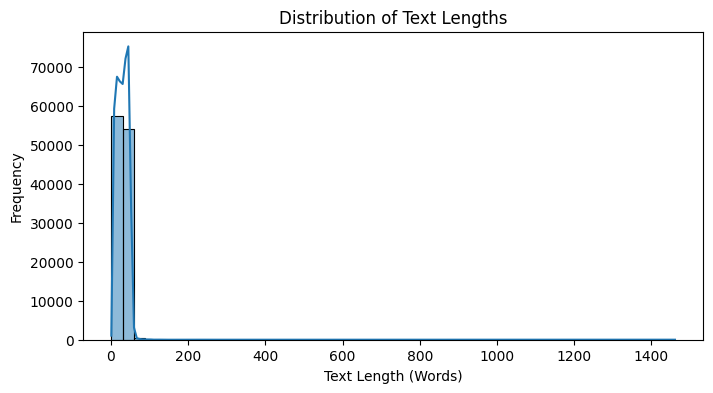

In [12]:
# Outputs
print(f"Number of training examples: {len(X_train_pc)}")
print(f"Number of dev examples: {len(X_val_pc)}")
print(f"Number of test examples: {len(X_test_pc)}")

# Compute lengths of cleaned texts
text_lengths = [len(doc.split()) for doc in X_train_pc]

# Compute statistics
min_length = np.min(text_lengths)
max_length = np.max(text_lengths)
mean_length = int(np.mean(text_lengths))
variance_length = int(np.var(text_lengths))
max_length_percentile = int(np.percentile(text_lengths, 90))

print("Length of training set after preprocessing:")
print(f"Min length: {min_length}")
print(f"Max length: {max_length}")
print(f"Mean length: {mean_length}")
print(f"Variance: {variance_length}")
print(f"90th percentile of text length {max_length_percentile}")

cv = np.std(text_lengths) / np.mean(text_lengths)  # Standard deviation / Mean
print(f"Coefficient of Variation: {cv:.2f}")

# Plot histogram
plt.figure(figsize=(8,4))
sns.histplot(text_lengths, bins=50, kde=True)
plt.xlabel("Text Length (Words)")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths")
plt.show()

- As we can see from the above results:
    - Mean length is 29 while the variance is too large (220), which means that there are many texts with length larger than the mean length.
    - the 90th percentile of the text length is 48, which may be more optimal choice for padding.

## **2. Functions**

### **2.1 Metrics** 
- classification report 
- precision recall AUC (per class/per classifier (macro))

#### **Interpolation:**
- Visualise average Precision Recall Curve
- `mean_recall = np.linspace(0, 1, 100).`: fix set of recall points, **this ensures that each class contributes equally spaced data points to the macro-averaged PR curve.**
- `mean_precision = np.mean(all_precisions, axis=0)` where:
    - `interp_prec = interp1d(rec, prec, kind="linear", bounds_error=False, fill_value=0)`
    - `all_precisions.append(interp_prec(mean_recall))`

### **2.2 Plot History**
- Accuracy vs Epochs
- F1 vs Epochs
- Losses vs Epochs

### **2.3 Train Model**

### **2.4 Evaluate Model**

In [13]:
def compute_metrics(y_true, y_pred, y_pred_proba, classifier_name, dataset_name):
    """Compute precision, recall, F1, and precision-recall AUC for multiclass classification."""

    # Print classification report (includes per-class & macro-averaged precision, recall, F1)
    print(f"=== {classifier_name} {dataset_name} Classification Report ===")
    report = classification_report(y_true, y_pred, digits=4)
    report1 = classification_report(y_true, y_pred, digits=4, output_dict=True)
    print(report)

    # Binarize labels for multi-class precision-recall AUC
    y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
    n_classes = y_true_bin.shape[1]

    # Store PR AUC per class
    pr_auc_scores = []

    all_precisions = []
    mean_recall = np.linspace(0, 1, 100)  # Common recall values for interpolation

    for i in range(n_classes):
        # Compute Precision-Recall Curve & AUC
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
        pr_auc = auc(rec, prec)
        pr_auc_scores.append(pr_auc)
        
        print(f"Class {i} Precision-Recall AUC: {pr_auc:.4f}")

        # Interpolate precision values to have a smooth average PR curve
        interp_prec = interp1d(rec, prec, kind="linear", bounds_error=False, fill_value=0)
        all_precisions.append(interp_prec(mean_recall))


    # Compute **Macro-Averaged Precision-Recall Curve**
    mean_precision = np.mean(all_precisions, axis=0)
    macro_pr_auc = auc(mean_recall, mean_precision)

    print(f"Macro Precision-Recall AUC: {macro_pr_auc:.4f}")


    return macro_pr_auc, report1, mean_precision, mean_recall 

def metrics(y_true, y_pred, y_pred_proba, classifier_name, dataset_name):
    """
    Computes and prints classification metrics for a given classifier and dataset.
    
    Parameters:
        y_true (array-like): True labels
        y_pred (array-like): Predicted labels
        y_pred_proba (array-like): Predicted probabilities for each class
        classifier_name (str): Name of the classifier
        dataset_name (str): Name of the dataset (e.g., "Validation", "Test")
    """
    print(f"=== {classifier_name} {dataset_name} ===")
    print("---------------------")
    print("Macro-averaged scores")
    
    # Binarize labels for multi-class precision-recall AUC
    y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
    n_classes = y_true_bin.shape[1]

    pr_auc_scores = []

    all_precisions = []
    mean_recall = np.linspace(0, 1, 100)  # Common recall values for interpolation
    
    for i in range(n_classes):
        # Compute Precision-Recall Curve & AUC
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
        pr_auc = auc(rec, prec)
        pr_auc_scores.append(pr_auc)
        # Interpolate precision values to have a smooth average PR curve
        interp_prec = interp1d(rec, prec, kind="linear", bounds_error=False, fill_value=0)
        all_precisions.append(interp_prec(mean_recall))

    # Compute **Macro-Averaged Precision-Recall Curve**
    mean_precision = np.mean(all_precisions, axis=0)
    macro_pr_auc = auc(mean_recall, mean_precision)

    # Compute and print macro-averaged precision, recall, and F1-score
    print("Precision score:", round(precision_score(y_true, y_pred, average="macro"), 4))
    print("Recall score:", round(recall_score(y_true, y_pred, average="macro"), 4))
    print("F1 score:", round(f1_score(y_true, y_pred, average="macro"), 4))
    print(f"AUC score: {macro_pr_auc:.4f}")

# 3. Train and evaluate models
def train_model(model, train_loader, val_loader, criterion, optimizer,
                epochs=20, patience=5):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []  # Track accuracy
    train_f1s, val_f1s = [], []  # Track F1 score
    best_val_loss = float('inf')  # Start with a large number
    best_model_path = None
    no_improvement_epochs = 0  # Counter for early stopping

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_preds = 0
        total_preds = 0
        y_true_train, y_pred_train = [], []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Calculate accuracy
            # torch.max function returns two values: the maximum values and the indices of the maximum values.
            _, predicted = torch.max(y_pred, dim=1) # gets the predicted class label by selecting the class with the highest probability
            correct_preds += (predicted == y_batch).sum().item() # counts the number of correct predictions by summing the True values 
            total_preds += y_batch.size(0)
            
            y_true_train.extend(y_batch.tolist())
            y_pred_train.extend(predicted.tolist())

        train_loss /= len(train_loader)
        train_accuracy = correct_preds / total_preds
        train_f1 = f1_score(y_true_train, y_pred_train, average='macro')  # F1 score (use micro, macro or weighted)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_f1s.append(train_f1)

        # Validation phase
        model.eval()
        val_loss = 0
        correct_preds = 0
        total_preds = 0
        y_true_val, y_pred_val = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
                
                # Calculate accuracy
                _, predicted = torch.max(y_pred, dim=1)
                correct_preds += (predicted == y_batch).sum().item()
                total_preds += y_batch.size(0)
                
                y_true_val.extend(y_batch.tolist())
                y_pred_val.extend(predicted.tolist())

        val_loss /= len(val_loader)
        val_accuracy = correct_preds / total_preds
        val_f1 = f1_score(y_true_val, y_pred_val, average='macro')  # F1 score (use micro, macro or weighted)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_f1s.append(val_f1)

        if epoch % 2 == 0:
            print(f'Epoch: {epoch+1} / {epochs} | Training Loss: {train_loss:.5f}, Validation Loss: {val_loss:.5f}')
            print(f'Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}')
            print(f'Training F1: {train_f1:.4f}, Validation F1: {val_f1:.4f}')

        # Early Stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            new_model_path = f'best_model_epoch_{epoch+1}.pth'
            if best_model_path is not None:
                os.remove(best_model_path)
            torch.save(model.state_dict(), new_model_path)
            best_model_path = new_model_path
            no_improvement_epochs = 0
        else:
            no_improvement_epochs += 1

        if no_improvement_epochs >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s


def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []  # y_prob will store probabilities for ROC curve
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch)
            probs = torch.softmax(preds, dim=1)  # Convert logits to probabilities
            preds = torch.argmax(probs, dim=1)  # Get predicted class (for metrics)
            
            y_true.extend(y_batch.tolist())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())  # Store probabilities for ROC curve

    # Convert lists to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    return y_true, y_pred, y_prob

def plot_history(train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s, model_name="Model"):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))  
    fig.suptitle(f"Training History of {model_name}", fontsize=16, fontweight="bold")  
    
    # Plot Accuracy
    axes[0].plot(train_accuracies, label='Train', marker='o')
    axes[0].plot(val_accuracies, label='Validation', marker='s')
    axes[0].set_title('Model Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)  

    # Plot Loss
    axes[1].plot(train_losses, label='Train', marker='o')
    axes[1].plot(val_losses, label='Validation', marker='s')
    axes[1].set_title('Model Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    # Plot F1 Score
    axes[2].plot(train_f1s, label='Train', marker='o')
    axes[2].plot(val_f1s, label='Validation', marker='s')
    axes[2].set_title('Model F1 Score')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout() 
    plt.show()

## **3. CNN**

In [14]:
# Create custom vocabulary using CountVectorizer
vectorizer = CountVectorizer(max_features=10000)
vectorizer.fit(X_train_pc)
custom_vocab = vectorizer.vocabulary_

# Load Word2Vec embeddings using gensim downloader
word2vec = api.load('word2vec-google-news-300')

# Map custom vocabulary to Word2Vec indices with 'PAD' and 'UNK' tokens
embedding_dim = 300
average_embedding = np.mean(word2vec.vectors, axis=0)  # average of all embeddings
vocab = {'PAD': 0, 'UNK': 1}
vocab.update({word: idx + 2 for idx, word in enumerate(custom_vocab)})
embedding_matrix = np.zeros((len(vocab), embedding_dim))
embedding_matrix[0] = np.zeros(embedding_dim)  # PAD token embedding
embedding_matrix[1] = average_embedding  # UNK token embedding
for word, idx in vocab.items():
    if word in word2vec:
        embedding_matrix[idx] = word2vec[word]
    elif idx > 1:
        embedding_matrix[idx] = average_embedding

del word2vec

In [17]:
len(custom_vocab)

200000

- Handling padding:
    - Instead of padding all sentences to a fixed maximum length (e.g., 1040), we dynamically pad each batch.
    - In each batch, shorter sentences are padded only up to the length of the longest sentence in that batch.
    - This avoids unnecessary padding, reduces memory usage, and improves computational efficiency.

In [15]:
# Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [self.tokenize(text, vocab) for text in texts]  # No max_length here
        self.labels = labels

    def tokenize(self, text, vocab):
        text = text.lower().split()
        tokens = [vocab.get(word, vocab['UNK']) for word in text]
        return tokens  # No manual padding

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx]), torch.tensor(self.labels[idx], dtype=torch.long) # Returning raw tokenized text (not tensor)

# Collate function for dynamic padding
def collate_batch(batch):
    """
        Custom collate function for dynamic padding in DataLoader.

        This function processes a batch of text sequences and labels:
        - Extracts the texts and labels from the batch.
        - Converts the text sequences into PyTorch tensors.
        - Applies dynamic padding using `pad_sequence()`, ensuring all sequences 
        in the batch are padded to match the longest sequence in that batch.
        - Converts the labels into a single tensor.

        Args:
            batch (list of tuples): Each tuple contains a tokenized text sequence (list of integers) 
                                    and its corresponding label.

        Returns:
            texts (torch.Tensor): A padded tensor of shape (batch_size, max_seq_len) 
                                where max_seq_len is the longest sequence in the batch.
            labels (torch.Tensor): A tensor of shape (batch_size,) containing the labels.
    """
    texts, labels = zip(*batch) # extract the text and labels from the batch 
    texts = [t.clone().detach() for t in texts]  # converts the text sequences into Pytorch tensors
    texts = torch.nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=vocab.get('PAD', 0)) # applies padding using `pad_sequence`
    labels = torch.tensor(labels, dtype=torch.long)  # Ensure labels are long tensors
    return texts, labels

# Create datasets
train_dataset = TextDataset(X_train_pc, y_train, vocab)
val_dataset = TextDataset(X_val_pc, y_val, vocab)
test_dataset = TextDataset(X_test_pc, y_test, vocab)

In [ ]:
# Define a CNN model with Global Max Pooling / Self-Attention
class CNNModel(nn.Module):
    def __init__(self, vocab_size,
                 embed_dim, output_dim, attention_dim=None,
                 num_filters=100, ngram_kernel_size=2,
                 pretrained_embeddings=True, freeze_embeddings=False,
                 num_layers=1,
                 use_pooling=False, use_attention=False,use_layernorm=False, dropout_rate_at=0.0,dropout_rate_cnn=0.0, stride_value=1):
        super(CNNModel, self).__init__()
        self.use_pooling = use_pooling
        self.use_attention = use_attention
        self.attention_mlp = None
        self.use_layernorm = use_layernorm
        self.dropout_attention = nn.Dropout(dropout_rate_at)
        self.dropout_cnn = nn.Dropout(dropout_rate_cnn)
        
        assert self.use_pooling or self.use_attention
        if self.use_pooling:
          assert not self.use_attention, "Cannot use pooling and attention at the same time"
        elif self.use_attention:
          assert not self.use_pooling, "Cannot use pooling and attention at the same time"

        if pretrained_embeddings:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0).from_pretrained(torch.tensor(embedding_matrix,
                                                                                                             dtype=torch.float32),
                                                                                                freeze=freeze_embeddings)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList() if self.use_layernorm else None 

        for layer_idx in range(num_layers):
          in_channels = embed_dim if layer_idx == 0 else num_filters
          kernel_size = ngram_kernel_size
          stride = stride_value
          dilation = 1  # Default value

          # Calculate "same" padding manually
          padding_value = (kernel_size - 1) // 2

          self.conv_layers.append(nn.Conv1d(in_channels=in_channels,
                                            out_channels=num_filters,
                                            kernel_size=ngram_kernel_size,
                                            stride=stride,
                                            padding=padding_value, 
                                            dilation=dilation))
          
          if self.use_layernorm:
                # First iteration: self.layer_norms = [ LayerNorm(num_filters) ]
                # Second iteration: # self.layer_norms = [ LayerNorm(num_filters), LayerNorm(num_filters) ]
                # .....
                self.layer_norms.append(nn.LayerNorm(num_filters))

           # Define pooling layer once
        if self.use_pooling:
            self.global_max_pooling = nn.AdaptiveMaxPool1d(output_size=1)

        self.fc = nn.Linear(num_filters, output_dim) 

        if self.use_attention:
          assert attention_dim is not None, "Attention dimension must be specified"
          self.attention_mlp = torch.nn.Sequential(
              torch.nn.Linear(num_filters, attention_dim),
              torch.nn.Tanh(),
              torch.nn.Linear(attention_dim, 1),
              torch.nn.Dropout(dropout_rate_at)
          )

    def forward(self, x):
        z = self.embedding(x)
        # Transpose x because Conv1d expects input of (batch_size, in_channels, sequence_length) where in_channels maps to our embedding_dim here
        z = z.transpose(1, 2)

        for layer_idx in range(len(self.conv_layers)):
          z = self.conv_layers[layer_idx](z)
          z = F.relu(z)  # Cleaner ReLU activation
          # First transpose(1, 2): Converts shape from (batch_size, num_filters, seq_length) → (batch_size, seq_length, num_filters), 
          # so that LayerNorm is applied over the num_filters dimension (which is the last dimension now).
          if self.use_layernorm:
                z = self.layer_norms[layer_idx](z.transpose(1, 2)).transpose(1, 2)
          z = self.dropout_cnn(z)  

        if self.use_pooling:
            z = self.global_max_pooling(z).squeeze()
            return self.fc(z)
        
        elif self.use_attention:
            attention_weights = self.attention_mlp(z.transpose(1, 2))  # (batch_size, sequence_length, 1)

           # give very large negative value to padding tokens to be zeroed-out by softmax
            padding_mask = (x == 0).unsqueeze(-1)  # (batch_size, sequence_length, 1)
            attention_weights -= 100000.0 * padding_mask.float()

            attention_weights = torch.softmax(attention_weights, dim=1)
            attention_output = torch.sum(z.transpose(1, 2) * attention_weights, dim=1)  # dot product
            return self.fc(attention_output)

In [ ]:
class MultiFilterCNNModel(nn.Module):
    def __init__(self, vocab_size,
                 embed_dim, output_dim, attention_dim=None,
                 num_filters=100,
                 pretrained_embeddings=True, freeze_embeddings=False,
                 num_layers=1,
                 use_pooling=False, use_attention=False, use_layernorm=False, dropout_rate=0.0):
        
        super(MultiFilterCNNModel, self).__init__()
        self.use_pooling = use_pooling
        self.use_attention = use_attention
        self.use_layernorm = use_layernorm
        self.attention_mlp = None

        assert self.use_pooling or self.use_attention, "Either pooling or attention must be used."
        assert not (self.use_pooling and self.use_attention), "Cannot use pooling and attention at the same time."

        if pretrained_embeddings:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0).from_pretrained(
                torch.tensor(embedding_matrix, dtype=torch.float32),
                freeze=freeze_embeddings
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.embeddings_projection = nn.Linear(embed_dim, num_filters)

        # Define dropout layer
        self.dropout = nn.Dropout(dropout_rate)

        # Define CNN layers
        self.bigram_layers = nn.ModuleList()
        self.trigram_layers = nn.ModuleList()
        self.fourgram_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList() if use_layernorm else None  # LayerNorm list

        for _ in range(num_layers):
            # padding=same: 1) output size matches the input size, preserving information across layers
            # 2) Avoids shrinking the sequence length after convolution
            self.bigram_layers.append(nn.Conv1d(num_filters, num_filters, kernel_size=2, padding='same'))
            self.trigram_layers.append(nn.Conv1d(num_filters, num_filters, kernel_size=3, padding='same'))
            self.fourgram_layers.append(nn.Conv1d(num_filters, num_filters, kernel_size=4, padding='same'))
            
            if self.use_layernorm:
                # Each CNN layer gets its own separate LayerNorm, preventing information leakage between layers.
                self.layer_norms.append(nn.LayerNorm(num_filters)) # each CNN layer has different activation distributions. 

        self.global_max_pooling = nn.AdaptiveMaxPool1d(output_size=1)
        self.fc = nn.Linear(num_filters * 3, output_dim)

        if self.use_attention:
            assert attention_dim is not None, "Attention dimension must be specified"
            self.attention_mlp = nn.Sequential(
                nn.Linear(num_filters * 3, attention_dim),
                nn.Tanh(),
                nn.Linear(attention_dim, 1),
                nn.Dropout(dropout_rate)
            )

    def forward(self, x):
        z = self.embedding(x)  # (batch_size, sequence_length, embed_dim)
        z = self.embeddings_projection(z)  # (batch_size, sequence_length, num_filters)
        
        z = self.dropout(z)
        z = z.transpose(1, 2)  # Conv1D expects (batch_size, num_filters, sequence_length)

        bigram, residual_bigram = z, z.clone()
        trigram, residual_trigram = z, z.clone()
        fourgram, residual_fourgram = z, z.clone()

        for i in range(len(self.bigram_layers)):
            bigram = torch.relu(self.bigram_layers[i](bigram)) + residual_bigram
            trigram = torch.relu(self.trigram_layers[i](trigram)) + residual_trigram
            fourgram = torch.relu(self.fourgram_layers[i](fourgram)) + residual_fourgram
            
            if self.use_layernorm:
                # Ensures normalization happens independently for each layer.
                bigram = self.layer_norms[i](bigram.transpose(1, 2)).transpose(1, 2)
                trigram = self.layer_norms[i](trigram.transpose(1, 2)).transpose(1, 2)
                fourgram = self.layer_norms[i](fourgram.transpose(1, 2)).transpose(1, 2)
            
            residual_bigram = bigram.clone()
            residual_trigram = trigram.clone()
            residual_fourgram = fourgram.clone()

        if self.use_pooling:
            bigram = self.global_max_pooling(bigram).squeeze()
            trigram = self.global_max_pooling(trigram).squeeze()
            fourgram = self.global_max_pooling(fourgram).squeeze()

        if self.use_attention:
            bigram_attention_weights = self.attention_mlp(bigram.transpose(1, 2))
            trigram_attention_weights = self.attention_mlp(trigram.transpose(1, 2))
            fourgram_attention_weights = self.attention_mlp(fourgram.transpose(1, 2))

            padding_mask = (x == 0).unsqueeze(-1)

            bigram_attention_weights = bigram_attention_weights.masked_fill(padding_mask, -1e9)
            trigram_attention_weights = trigram_attention_weights.masked_fill(padding_mask, -1e9)
            fourgram_attention_weights = fourgram_attention_weights.masked_fill(padding_mask, -1e9)

            bigram_attention_weights = torch.softmax(bigram_attention_weights, dim=1)
            trigram_attention_weights = torch.softmax(trigram_attention_weights, dim=1)
            fourgram_attention_weights = torch.softmax(fourgram_attention_weights, dim=1)

            bigram = torch.sum(bigram.transpose(1, 2) * bigram_attention_weights, dim=1)
            trigram = torch.sum(trigram.transpose(1, 2) * trigram_attention_weights, dim=1)
            fourgram = torch.sum(fourgram.transpose(1, 2) * fourgram_attention_weights, dim=1)

        output = torch.cat((bigram, trigram, fourgram), dim=1)
        return self.fc(output)

Epoch: 1 / 180 | Training Loss: 2.38401, Validation Loss: 1.83986
Training Accuracy: 0.2866, Validation Accuracy: 0.4559
Training F1: 0.2230, Validation F1: 0.3767
Epoch: 3 / 180 | Training Loss: 0.62318, Validation Loss: 0.49816
Training Accuracy: 0.8575, Validation Accuracy: 0.8774
Training F1: 0.8540, Validation F1: 0.8760
Epoch: 5 / 180 | Training Loss: 0.34291, Validation Loss: 0.31900
Training Accuracy: 0.9069, Validation Accuracy: 0.9125
Training F1: 0.9067, Validation F1: 0.9121
Epoch: 7 / 180 | Training Loss: 0.25652, Validation Loss: 0.24939
Training Accuracy: 0.9275, Validation Accuracy: 0.9291
Training F1: 0.9274, Validation F1: 0.9289
Epoch: 9 / 180 | Training Loss: 0.21061, Validation Loss: 0.20973
Training Accuracy: 0.9398, Validation Accuracy: 0.9396
Training F1: 0.9398, Validation F1: 0.9395
Epoch: 11 / 180 | Training Loss: 0.18102, Validation Loss: 0.18521
Training Accuracy: 0.9482, Validation Accuracy: 0.9471
Training F1: 0.9482, Validation F1: 0.9471
Epoch: 13 / 180

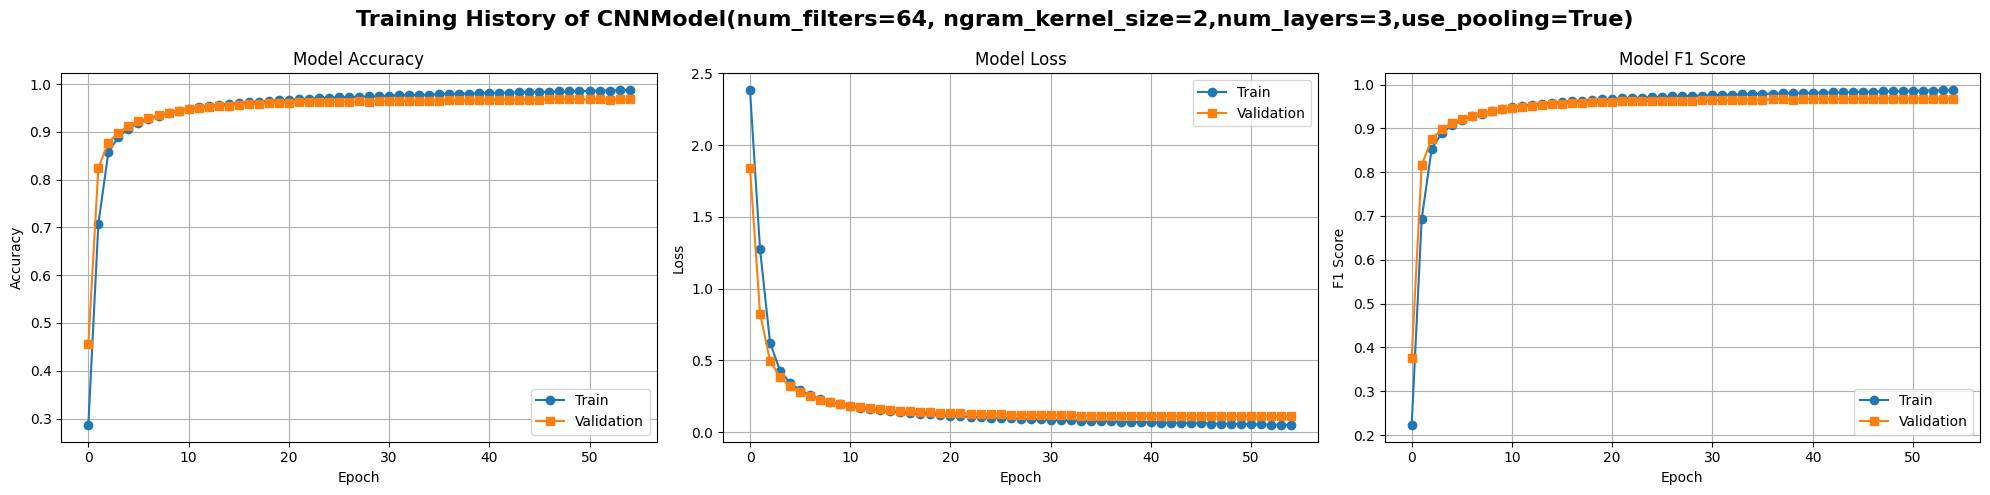

In [45]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 180
num_classes = len(np.unique(y_train))

model = CNNModel(vocab_size=len(vocab), embed_dim=300,
                              output_dim=num_classes,
                              num_filters=64, ngram_kernel_size=2,
                              num_layers=3,
                              use_pooling=True)
model = model.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train, y_pred_train, y_prob_train = evaluate_model(model, train_loader)
y_true_val, y_pred_val, y_prob_val = evaluate_model(model, val_loader)  # Fixed typo

plot_history(train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s, model_name="CNNModel(num_filters=64, ngram_kernel_size=2,num_layers=3,use_pooling=True)")

Epoch: 1 / 180 | Training Loss: 2.30716, Validation Loss: 1.53521
Training Accuracy: 0.2573, Validation Accuracy: 0.6737
Training F1: 0.2348, Validation F1: 0.6327
Epoch: 3 / 180 | Training Loss: 0.38188, Validation Loss: 0.30413
Training Accuracy: 0.9072, Validation Accuracy: 0.9203
Training F1: 0.9067, Validation F1: 0.9205
Epoch: 5 / 180 | Training Loss: 0.21275, Validation Loss: 0.20144
Training Accuracy: 0.9404, Validation Accuracy: 0.9432
Training F1: 0.9403, Validation F1: 0.9433
Epoch: 7 / 180 | Training Loss: 0.16685, Validation Loss: 0.16676
Training Accuracy: 0.9522, Validation Accuracy: 0.9524
Training F1: 0.9522, Validation F1: 0.9524
Epoch: 9 / 180 | Training Loss: 0.14208, Validation Loss: 0.14702
Training Accuracy: 0.9590, Validation Accuracy: 0.9579
Training F1: 0.9589, Validation F1: 0.9578
Epoch: 11 / 180 | Training Loss: 0.12518, Validation Loss: 0.13460
Training Accuracy: 0.9639, Validation Accuracy: 0.9613
Training F1: 0.9639, Validation F1: 0.9613
Epoch: 13 / 180

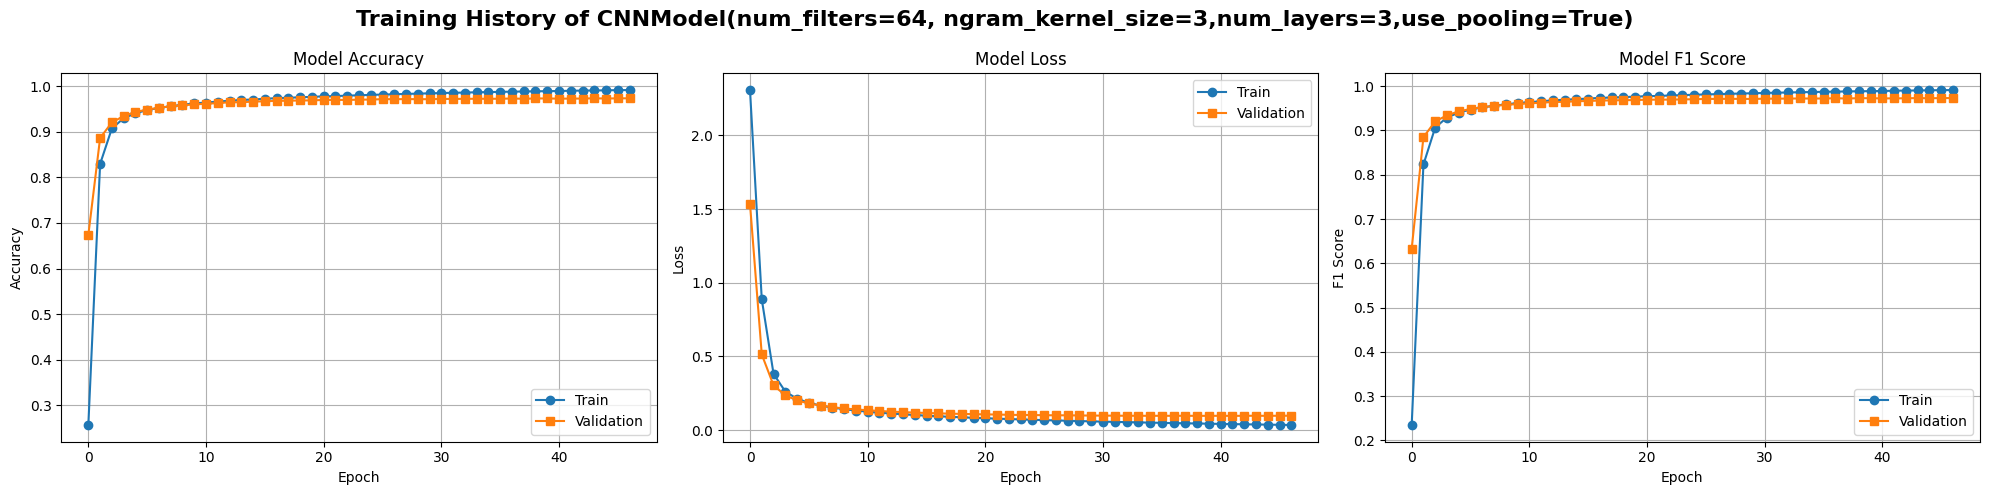

In [46]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 180
num_classes = len(np.unique(y_train))

model1 = CNNModel(vocab_size=len(vocab), embed_dim=300,
                               output_dim=num_classes,
                               num_filters=64, ngram_kernel_size=3,
                               num_layers=3,
                               use_pooling=True)
model1 = model1.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.00001)

train_losses1, val_losses1, train_accuracies1, val_accuracies1, train_f1s1, val_f1s1 = train_model(
    model1, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train1, y_pred_train1, y_prob_train1 = evaluate_model(model1, train_loader)
y_true_val1, y_pred_val1, y_prob_val1 = evaluate_model(model1, val_loader)  # Fixed typo

plot_history(train_losses1, val_losses1, train_accuracies1, val_accuracies1, train_f1s1, val_f1s1, model_name="CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True)")

Epoch: 1 / 180 | Training Loss: 2.07884, Validation Loss: 1.10399
Training Accuracy: 0.3941, Validation Accuracy: 0.7917
Training F1: 0.3961, Validation F1: 0.7886
Epoch: 3 / 180 | Training Loss: 0.40569, Validation Loss: 0.27493
Training Accuracy: 0.8934, Validation Accuracy: 0.9296
Training F1: 0.8929, Validation F1: 0.9291
Epoch: 5 / 180 | Training Loss: 0.24180, Validation Loss: 0.19377
Training Accuracy: 0.9337, Validation Accuracy: 0.9490
Training F1: 0.9335, Validation F1: 0.9486
Epoch: 7 / 180 | Training Loss: 0.18566, Validation Loss: 0.15612
Training Accuracy: 0.9480, Validation Accuracy: 0.9580
Training F1: 0.9479, Validation F1: 0.9578
Epoch: 9 / 180 | Training Loss: 0.15324, Validation Loss: 0.13576
Training Accuracy: 0.9567, Validation Accuracy: 0.9624
Training F1: 0.9566, Validation F1: 0.9622
Epoch: 11 / 180 | Training Loss: 0.13203, Validation Loss: 0.12378
Training Accuracy: 0.9631, Validation Accuracy: 0.9646
Training F1: 0.9631, Validation F1: 0.9644
Epoch: 13 / 180

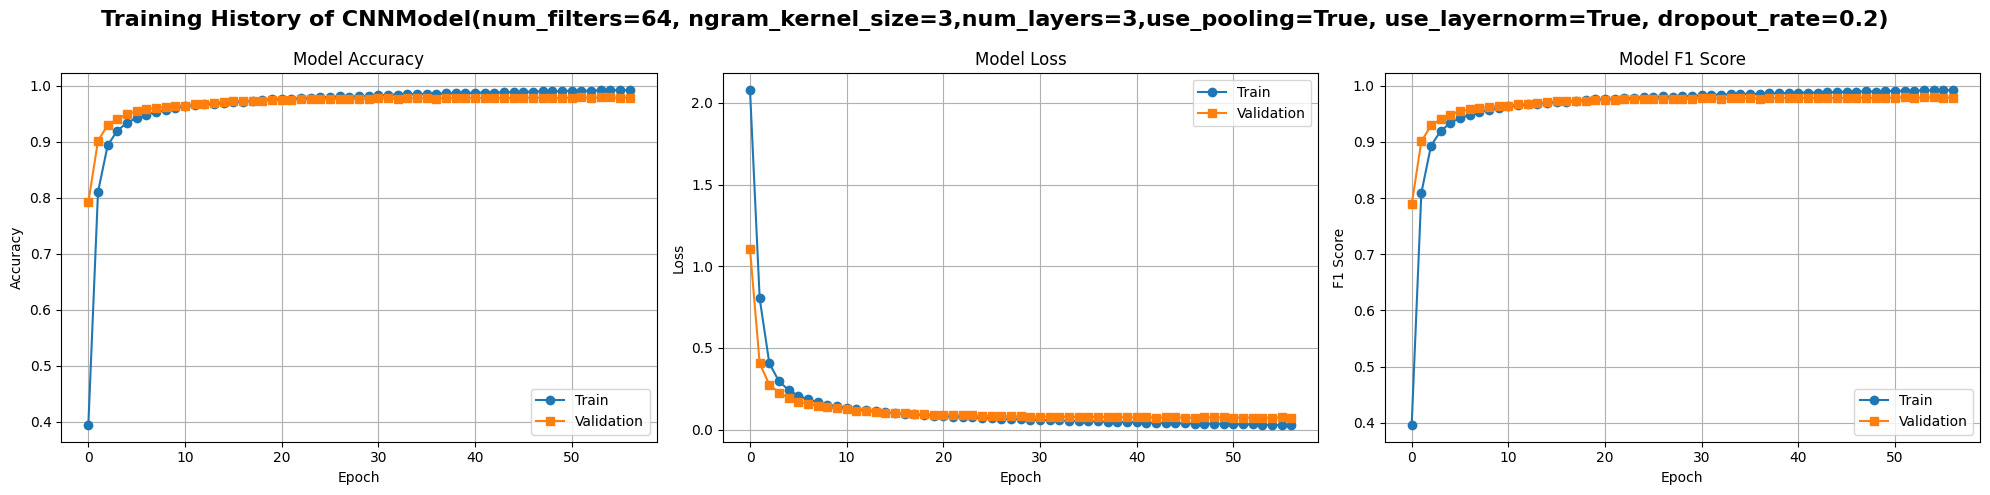

In [ ]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 180
num_classes = len(np.unique(y_train))

model5 = CNNModel(vocab_size=len(vocab), embed_dim=300,
                               output_dim=num_classes,
                               num_filters=64, ngram_kernel_size=3,
                               num_layers=3,
                               use_pooling=True, use_layernorm=True, dropout_rate_cnn=0.2)
model5 = model5.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model5.parameters(), lr=0.00001)

train_losses5, val_losses5, train_accuracies5, val_accuracies5, train_f1s5, val_f1s5 = train_model(
    model5, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train5, y_pred_train5, y_prob_train5 = evaluate_model(model5, train_loader)
y_true_val5, y_pred_val5, y_prob_val5 = evaluate_model(model5, val_loader)  
y_true_test5, y_pred_test5, y_prob_test5 = evaluate_model(model5, test_loader)  

plot_history(train_losses5, val_losses5, train_accuracies5, val_accuracies5, train_f1s5, val_f1s5, model_name="CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2)")

Epoch: 1 / 200 | Training Loss: 1.08094, Validation Loss: 0.27626
Training Accuracy: 0.7714, Validation Accuracy: 0.9309
Training F1: 0.7665, Validation F1: 0.9303
Epoch: 3 / 200 | Training Loss: 0.18599, Validation Loss: 0.13215
Training Accuracy: 0.9516, Validation Accuracy: 0.9618
Training F1: 0.9515, Validation F1: 0.9618
Epoch: 5 / 200 | Training Loss: 0.13002, Validation Loss: 0.10765
Training Accuracy: 0.9641, Validation Accuracy: 0.9687
Training F1: 0.9640, Validation F1: 0.9686
Epoch: 7 / 200 | Training Loss: 0.10510, Validation Loss: 0.09259
Training Accuracy: 0.9706, Validation Accuracy: 0.9723
Training F1: 0.9706, Validation F1: 0.9723
Epoch: 9 / 200 | Training Loss: 0.09025, Validation Loss: 0.08694
Training Accuracy: 0.9743, Validation Accuracy: 0.9734
Training F1: 0.9743, Validation F1: 0.9733
Epoch: 11 / 200 | Training Loss: 0.07962, Validation Loss: 0.08227
Training Accuracy: 0.9777, Validation Accuracy: 0.9755
Training F1: 0.9777, Validation F1: 0.9755
Epoch: 13 / 200

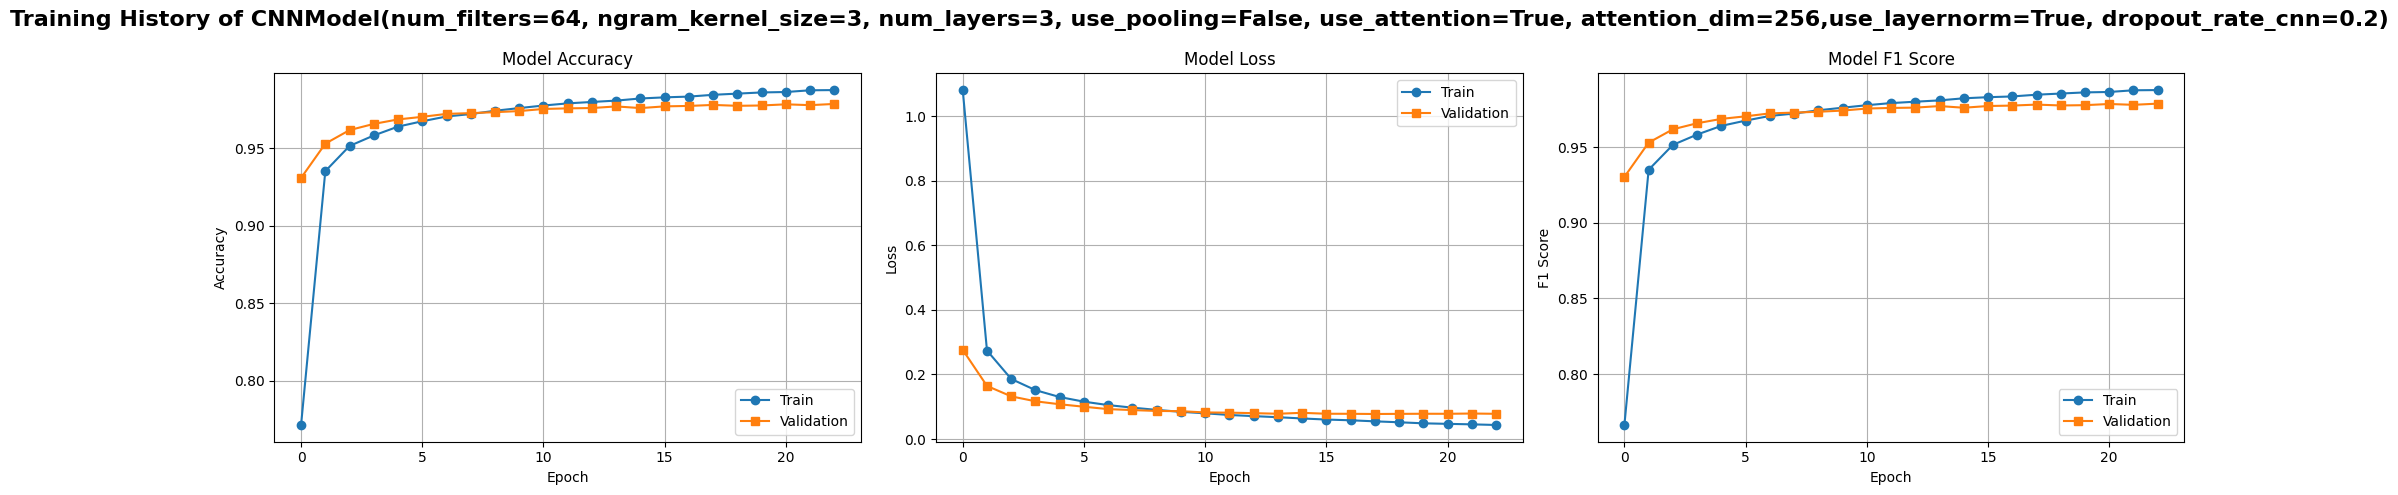

In [24]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 200
num_classes = len(np.unique(y_train))

model13 = CNNModel(vocab_size=len(vocab), embed_dim=300,
                               output_dim=num_classes,
                               num_filters=128, ngram_kernel_size=3,
                               num_layers=3,
                               use_pooling=False, use_attention=True, attention_dim=256, use_layernorm=True, dropout_rate_cnn=0.3)
model13 = model13.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model13.parameters(), lr=0.00001)

train_losses13, val_losses13, train_accuracies13, val_accuracies13, train_f1s13, val_f1s13 = train_model(
    model13, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train13, y_pred_train13, y_prob_train13 = evaluate_model(model13, train_loader)
y_true_val13, y_pred_val13, y_prob_val13 = evaluate_model(model13, val_loader)  

plot_history(train_losses13, val_losses13, train_accuracies13, val_accuracies13, train_f1s13, val_f1s13, model_name = "CNNModel(num_filters=64, ngram_kernel_size=3, num_layers=3, use_pooling=False, use_attention=True, attention_dim=256,use_layernorm=True, dropout_rate_cnn=0.2)")

Epoch: 1 / 180 | Training Loss: 2.57934, Validation Loss: 2.48027
Training Accuracy: 0.1692, Validation Accuracy: 0.2596
Training F1: 0.0871, Validation F1: 0.1809
Epoch: 3 / 180 | Training Loss: 2.03377, Validation Loss: 1.86524
Training Accuracy: 0.5809, Validation Accuracy: 0.5939
Training F1: 0.5151, Validation F1: 0.5190
Epoch: 5 / 180 | Training Loss: 1.38917, Validation Loss: 1.26940
Training Accuracy: 0.6748, Validation Accuracy: 0.7193
Training F1: 0.6301, Validation F1: 0.6931
Epoch: 7 / 180 | Training Loss: 0.93164, Validation Loss: 0.85643
Training Accuracy: 0.8418, Validation Accuracy: 0.8570
Training F1: 0.8369, Validation F1: 0.8548
Epoch: 9 / 180 | Training Loss: 0.64590, Validation Loss: 0.60976
Training Accuracy: 0.8903, Validation Accuracy: 0.8911
Training F1: 0.8902, Validation F1: 0.8915
Epoch: 11 / 180 | Training Loss: 0.48383, Validation Loss: 0.46954
Training Accuracy: 0.9074, Validation Accuracy: 0.9051
Training F1: 0.9077, Validation F1: 0.9057
Epoch: 13 / 180

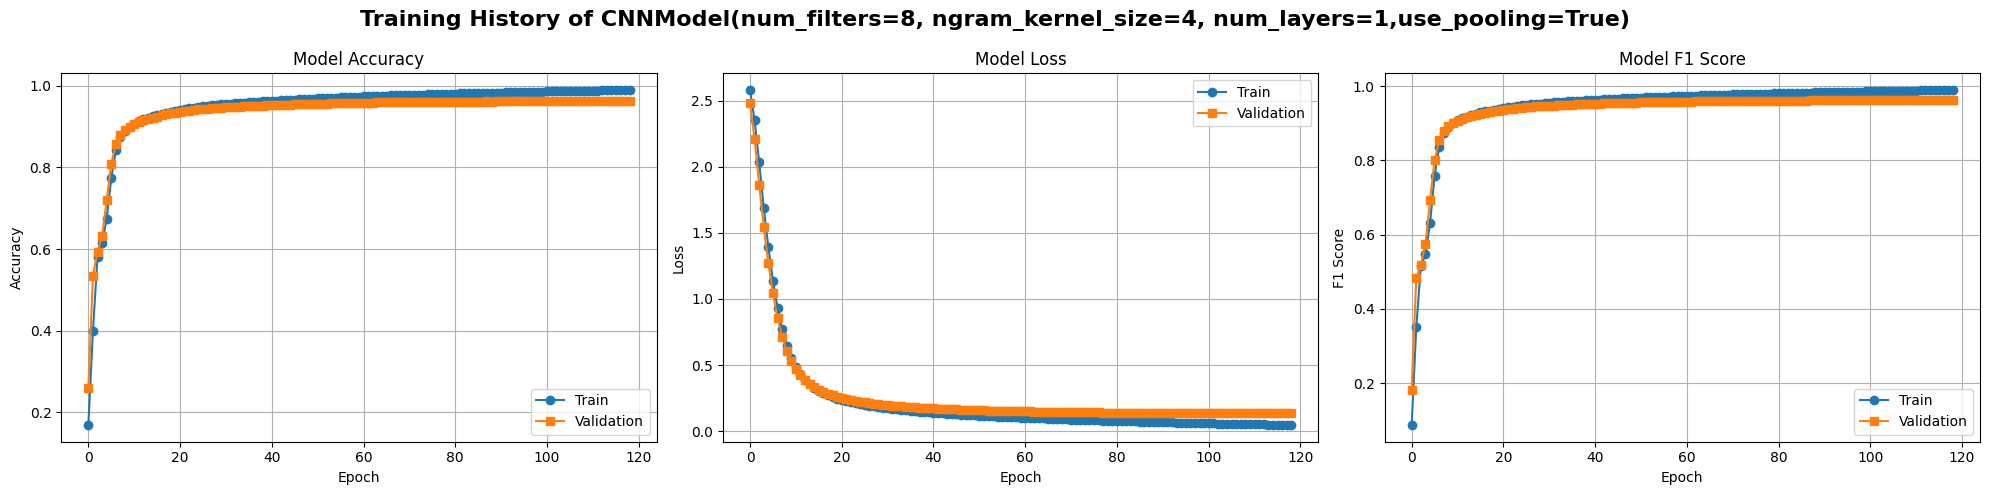

In [47]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 180
num_classes = len(np.unique(y_train))

model2 = CNNModel(vocab_size=len(vocab), embed_dim=300,
                               output_dim=num_classes,
                               num_filters=8, ngram_kernel_size=4, num_layers=1,
                               use_pooling=True)
model2 = model2.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.00001)

train_losses2, val_losses2, train_accuracies2, val_accuracies2, train_f1s2, val_f1s2 = train_model(
    model2, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train2, y_pred_train2, y_prob_train2 = evaluate_model(model2, train_loader)
y_true_val2, y_pred_val2, y_prob_val2 = evaluate_model(model2, val_loader) 

plot_history(train_losses2, val_losses2, train_accuracies2, val_accuracies2, train_f1s2, val_f1s2, model_name="CNNModel(num_filters=8, ngram_kernel_size=4, num_layers=1,use_pooling=True)")

Epoch: 1 / 180 | Training Loss: 2.50355, Validation Loss: 2.26525
Training Accuracy: 0.2296, Validation Accuracy: 0.4629
Training F1: 0.1652, Validation F1: 0.4308
Epoch: 3 / 180 | Training Loss: 1.03783, Validation Loss: 0.76888
Training Accuracy: 0.8327, Validation Accuracy: 0.8663
Training F1: 0.8279, Validation F1: 0.8645
Epoch: 5 / 180 | Training Loss: 0.41518, Validation Loss: 0.36625
Training Accuracy: 0.9016, Validation Accuracy: 0.9082
Training F1: 0.9013, Validation F1: 0.9079
Epoch: 7 / 180 | Training Loss: 0.26879, Validation Loss: 0.25887
Training Accuracy: 0.9283, Validation Accuracy: 0.9283
Training F1: 0.9282, Validation F1: 0.9282
Epoch: 9 / 180 | Training Loss: 0.21136, Validation Loss: 0.21206
Training Accuracy: 0.9407, Validation Accuracy: 0.9390
Training F1: 0.9406, Validation F1: 0.9389
Epoch: 11 / 180 | Training Loss: 0.18070, Validation Loss: 0.18619
Training Accuracy: 0.9479, Validation Accuracy: 0.9446
Training F1: 0.9478, Validation F1: 0.9445
Epoch: 13 / 180

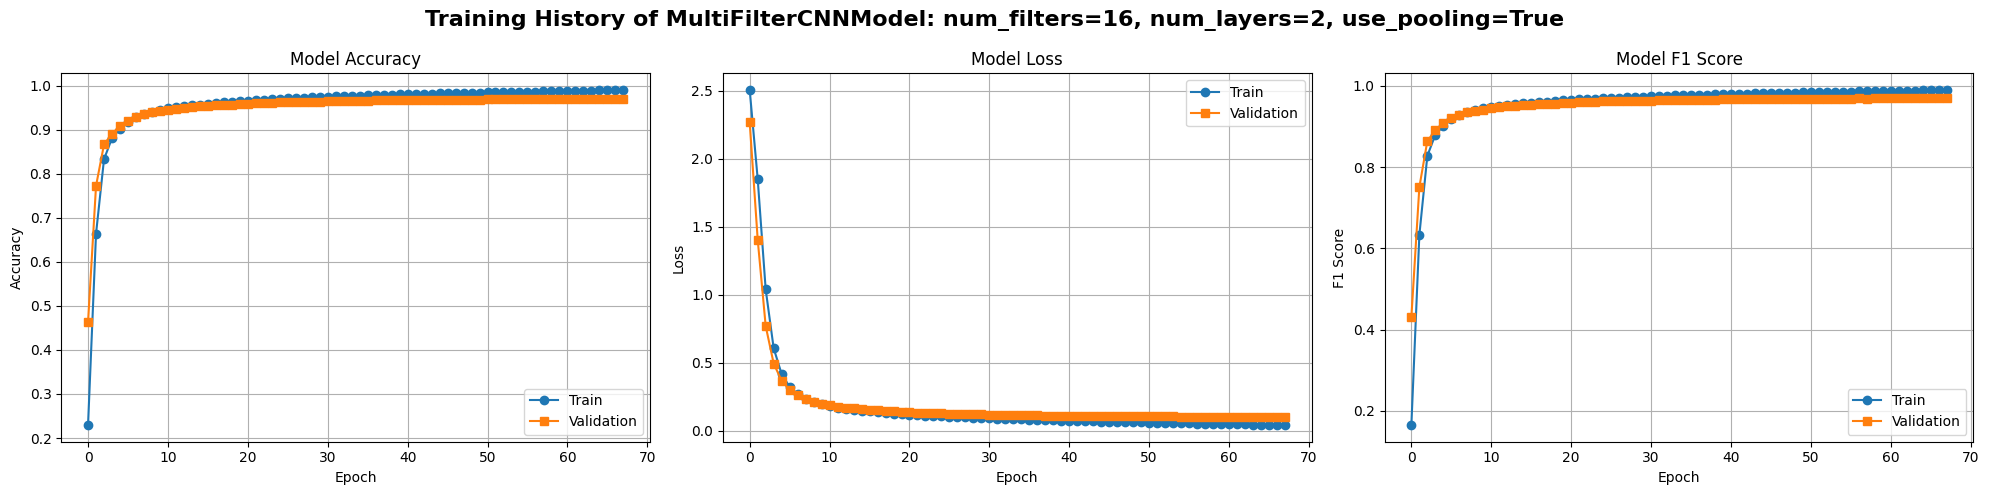

In [32]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 180
num_classes = len(np.unique(y_train))

model4 = MultiFilterCNNModel(
                            vocab_size=len(vocab), embed_dim=300, output_dim=num_classes,
                            num_filters=16, num_layers=2, use_pooling=True)

model4 = model4.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model4.parameters(), lr=0.00001)

train_losses4, val_losses4, train_accuracies4, val_accuracies4, train_f1s4, val_f1s4 = train_model(
    model4, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train4, y_pred_train4, y_prob_train4 = evaluate_model(model4, train_loader)
y_true_val4, y_pred_val4, y_prob_val4 = evaluate_model(model4, val_loader) 

plot_history(train_losses4, val_losses4, train_accuracies4, val_accuracies4, train_f1s4, val_f1s4, model_name="MultiFilterCNNModel: num_filters=16, num_layers=2, use_pooling=True")

Epoch: 1 / 180 | Training Loss: 2.37800, Validation Loss: 1.86354
Training Accuracy: 0.3435, Validation Accuracy: 0.6754
Training F1: 0.3419, Validation F1: 0.6567
Epoch: 3 / 180 | Training Loss: 1.13882, Validation Loss: 0.87098
Training Accuracy: 0.8255, Validation Accuracy: 0.8672
Training F1: 0.8209, Validation F1: 0.8640
Epoch: 5 / 180 | Training Loss: 0.60746, Validation Loss: 0.47384
Training Accuracy: 0.8870, Validation Accuracy: 0.9110
Training F1: 0.8859, Validation F1: 0.9101
Epoch: 7 / 180 | Training Loss: 0.39658, Validation Loss: 0.32231
Training Accuracy: 0.9112, Validation Accuracy: 0.9277
Training F1: 0.9107, Validation F1: 0.9272
Epoch: 9 / 180 | Training Loss: 0.30502, Validation Loss: 0.25456
Training Accuracy: 0.9248, Validation Accuracy: 0.9377
Training F1: 0.9245, Validation F1: 0.9374
Epoch: 11 / 180 | Training Loss: 0.25543, Validation Loss: 0.21705
Training Accuracy: 0.9337, Validation Accuracy: 0.9442
Training F1: 0.9334, Validation F1: 0.9439
Epoch: 13 / 180

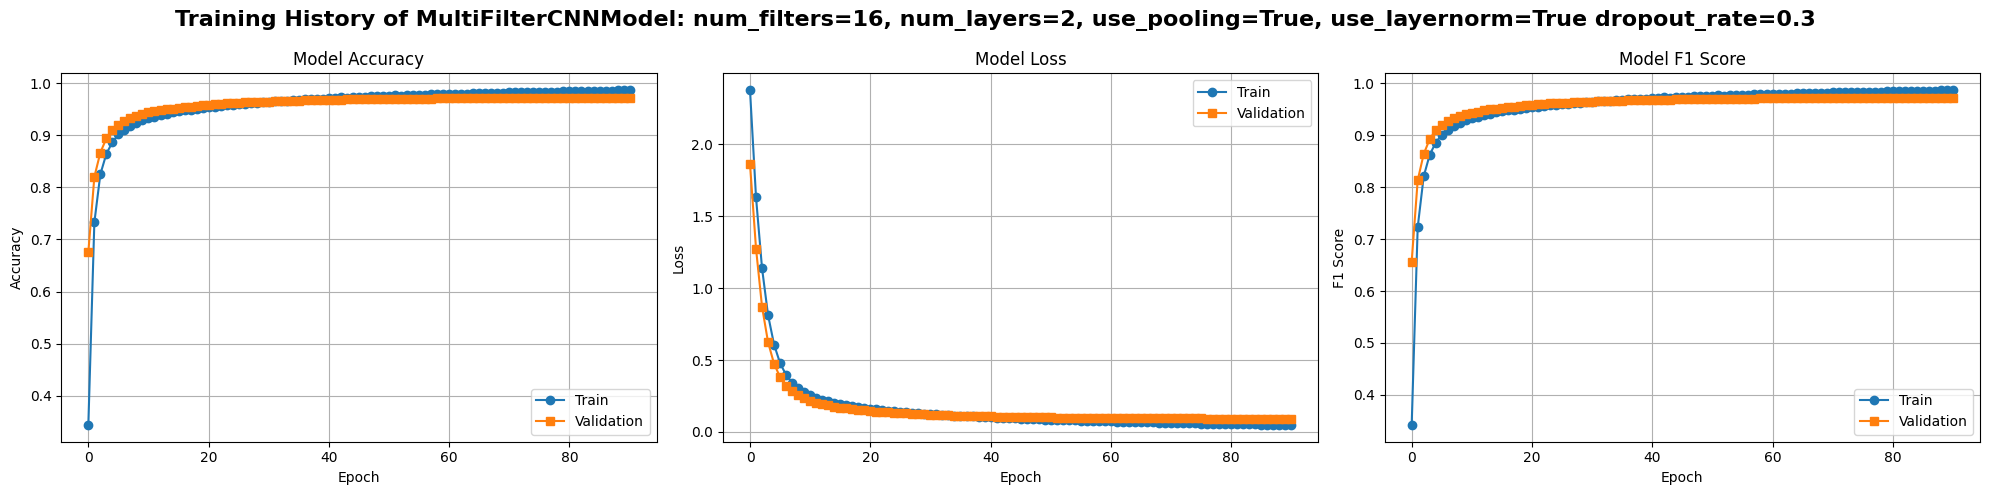

In [49]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 180
num_classes = len(np.unique(y_train))

model6 = MultiFilterCNNModel(
                            vocab_size=len(vocab), embed_dim=300, output_dim=num_classes,
                            num_filters=16, num_layers=2, use_pooling=True, use_layernorm=True, dropout_rate=0.2)

model6 = model6.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model6.parameters(), lr=0.00001)

train_losses6, val_losses6, train_accuracies6, val_accuracies6, train_f1s6, val_f1s6 = train_model(
    model6, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train6, y_pred_train6, y_prob_train6 = evaluate_model(model6, train_loader)
y_true_val6, y_pred_val6, y_prob_val6 = evaluate_model(model6, val_loader) 
y_true_test6, y_pred_test6, y_prob_test6 = evaluate_model(model6, test_loader) 


plot_history(train_losses6, val_losses6, train_accuracies6, val_accuracies6, train_f1s6, val_f1s6, model_name="MultiFilterCNNModel: num_filters=16, num_layers=2, use_pooling=True, use_layernorm=True dropout_rate=0.2")

Epoch: 1 / 180 | Training Loss: 2.41898, Validation Loss: 1.96389
Training Accuracy: 0.3110, Validation Accuracy: 0.6278
Training F1: 0.2970, Validation F1: 0.6153
Epoch: 3 / 180 | Training Loss: 1.24707, Validation Loss: 0.96084
Training Accuracy: 0.8142, Validation Accuracy: 0.8697
Training F1: 0.8093, Validation F1: 0.8667
Epoch: 5 / 180 | Training Loss: 0.65655, Validation Loss: 0.50216
Training Accuracy: 0.8940, Validation Accuracy: 0.9156
Training F1: 0.8928, Validation F1: 0.9147
Epoch: 7 / 180 | Training Loss: 0.40019, Validation Loss: 0.31473
Training Accuracy: 0.9223, Validation Accuracy: 0.9344
Training F1: 0.9218, Validation F1: 0.9339
Epoch: 9 / 180 | Training Loss: 0.28503, Validation Loss: 0.23226
Training Accuracy: 0.9357, Validation Accuracy: 0.9437
Training F1: 0.9355, Validation F1: 0.9434
Epoch: 11 / 180 | Training Loss: 0.22682, Validation Loss: 0.19017
Training Accuracy: 0.9449, Validation Accuracy: 0.9506
Training F1: 0.9447, Validation F1: 0.9504
Epoch: 13 / 180

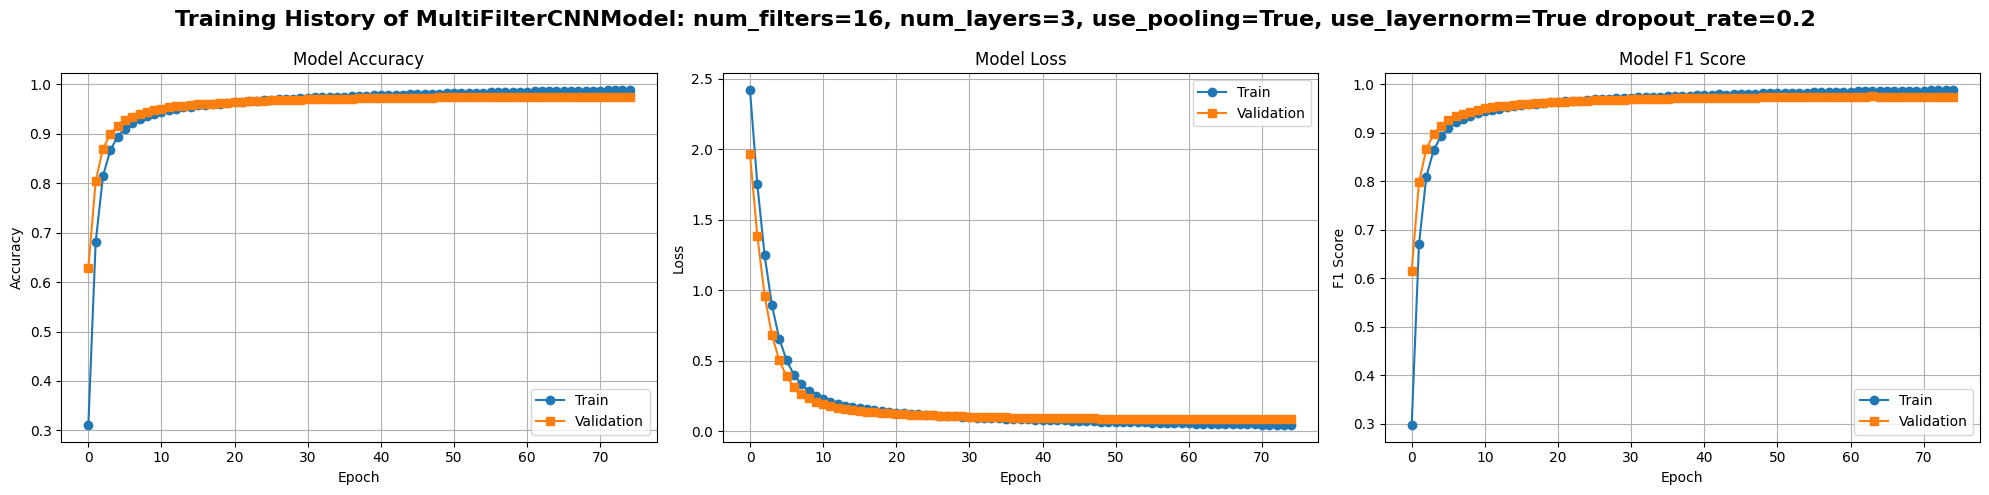

In [54]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 180
num_classes = len(np.unique(y_train))

model7 = MultiFilterCNNModel(
                            vocab_size=len(vocab), embed_dim=300, output_dim=num_classes,
                            num_filters=16, num_layers=3, use_pooling=True, use_layernorm=True, dropout_rate=0.2)

model7 = model7.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model7.parameters(), lr=0.00001)

train_losses7, val_losses7, train_accuracies7, val_accuracies7, train_f1s7, val_f1s7 = train_model(
    model7, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train7, y_pred_train7, y_prob_train7 = evaluate_model(model7, train_loader)
y_true_val7, y_pred_val7, y_prob_val7 = evaluate_model(model7, val_loader) 
y_true_test7, y_pred_test7, y_prob_test7 = evaluate_model(model7, test_loader) 


plot_history(train_losses7, val_losses7, train_accuracies7, val_accuracies7, train_f1s7, val_f1s7, model_name="MultiFilterCNNModel: num_filters=16, num_layers=3, use_pooling=True, use_layernorm=True dropout_rate=0.2")

### **3.3 Results**

**Best CNN model: CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2)**

In [ ]:
# Train set
print("Train Set")
metrics(y_true_train5, y_pred_train5, y_prob_train5, "CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2)", "Train")
print()
print()
print()
# Validation Set
print("Validation Set")
metrics(y_true_val5, y_pred_val5, y_prob_val5, "CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2)", "Validation")
print()
print()
print()
# Test set
print("Test Set")
metrics(y_true_test5, y_pred_test5, y_prob_test5, "CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2)", "Test")

Train Set
=== CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2) Train ===
---------------------
Macro-averaged scores
Precision score: 0.9971
Recall score: 0.9971
F1 score: 0.9971
AUC score: 0.9986



Validation Set
=== CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2) Validation ===
---------------------
Macro-averaged scores
Precision score: 0.9788
Recall score: 0.9788
F1 score: 0.9788
AUC score: 0.9938



Test Set
=== CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2) Test ===
---------------------
Macro-averaged scores
Precision score: 0.9773
Recall score: 0.9774
F1 score: 0.9773
AUC score: 0.9945


In [34]:
print("Train Set")
macro_pr_auc_train, report1_train, mean_precision_train, mean_recall_train =compute_metrics(y_true_train5, y_pred_train5, y_prob_train5, "CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2)", "Train")
print()
print()
print()
print("Validation Set")
macro_pr_auc_val, report1_val, mean_precision_val, mean_recall_val =compute_metrics(y_true_val5, y_pred_val5, y_prob_val5, "CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2)", "Train")
print()
print()
print()
print("Test Set")
macro_pr_auc_test, report1_test, mean_precision_test, mean_recall_test =compute_metrics(y_true_test5, y_pred_test5, y_prob_test5, "CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2)", "Train")

Train Set
=== CNNModel(num_filters=64, ngram_kernel_size=3,num_layers=3,use_pooling=True, use_layernorm=True, dropout_rate=0.2) Train Classification Report ===
              precision    recall  f1-score   support

           0     0.9962    0.9902    0.9932      8026
           1     0.9950    0.9980    0.9965      8009
           2     0.9945    0.9959    0.9952      7971
           3     0.9997    0.9987    0.9992      7930
           4     0.9970    0.9955    0.9962      7959
           5     0.9989    0.9991    0.9990      8018
           6     0.9952    0.9962    0.9957      7992
           7     0.9982    0.9995    0.9989      7951
           8     0.9988    0.9994    0.9991      8046
           9     0.9955    0.9984    0.9969      7975
          10     0.9986    0.9947    0.9966      8040
          11     0.9969    0.9996    0.9983      8017
          12     0.9984    0.9980    0.9982      8046
          13     0.9968    0.9966    0.9967      8020

    accuracy                

## **4. RNN**

In [25]:
class CustomAttention(nn.Module):
    def __init__(self, hidden_dim, attention_dim=None, use_second_attention=False, dropout_rate=0.1, bidirectional=False):
        super(CustomAttention, self).__init__()

        self.use_attention = attention_dim is not None  # Only use attention if attention_dim is set

        scale = 2 if bidirectional else 1
        self.hidden_dim = scale * hidden_dim 

        self.attention_dim = attention_dim
        self.use_second_attention = use_second_attention  # Flag for second attention mechanism

        if self.use_attention:
            # First attention mechanism (MLP attention)
            self.attention_layer_1 = nn.Sequential(
                nn.Linear(self.hidden_dim, attention_dim),
                nn.ReLU(),
                nn.Linear(attention_dim, 1),
                nn.Dropout(dropout_rate)
            )

            # Second attention mechanism (more complex structure)
            self.attention_layer_2 = nn.Sequential(
                nn.Linear(self.hidden_dim, attention_dim),
                nn.ReLU(),
                nn.Linear(attention_dim, attention_dim // 2),
                nn.ReLU(),
                nn.Linear(attention_dim // 2, 1),
                nn.Dropout(dropout_rate)
            )


    def forward(self, rnn_outputs, padding_mask=None):
        if not self.use_attention:
            return rnn_outputs[:, -1, :], None  # Return last hidden state without attention

        # Select the correct attention layer
        attention_layer = self.attention_layer_2 if self.use_second_attention else self.attention_layer_1
        
        # Apply attention
        attention_weights = attention_layer(rnn_outputs)  # (batch_size, seq_len, 1)

        if padding_mask is not None:
            attention_weights -= 100000.0 * padding_mask.float()

        attention_weights = torch.softmax(attention_weights, dim=1)
        attention_output = torch.sum(rnn_outputs * attention_weights, dim=1)  # Weighted sum

        return attention_output, attention_weights



class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, attention_dim=None,
                 model_type='RNN', pretrained=True, freeze=False, num_layers=1,
                 bidirectional=False, use_pooling=False, use_attention=False, dropout_rate_rnn=0.2, dropout_rate_at=0.1, 
                 use_second_attention=False, use_layer_norm=False):
        super(RNNModel, self).__init__()

        self.use_pooling = use_pooling
        self.use_attention = use_attention
        self.use_layer_norm = use_layer_norm

        scale = 2 if bidirectional else 1

        if self.use_pooling:
            assert not self.use_attention, "Cannot use pooling and attention at the same time"
        elif self.use_attention:
            assert not self.use_pooling, "Cannot use pooling and attention at the same time"

        if pretrained:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0).from_pretrained(
                torch.tensor(embedding_matrix, dtype=torch.float32), freeze=freeze
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        rnn_class = {'RNN': nn.RNN, 'GRU': nn.GRU, 'LSTM': nn.LSTM}[model_type]
        
        # Ensure dropout is applied only if num_layers > 1
        rnn_dropout = dropout_rate_rnn if num_layers > 1 else 0
        self.rnn = rnn_class(embed_dim, hidden_dim, batch_first=True, num_layers=num_layers, 
                             bidirectional=bidirectional, dropout=rnn_dropout)
        self.fc = nn.Linear(scale * hidden_dim, output_dim)

        # Layer Normalization (Only if enabled)
        if self.use_layer_norm:
            self.layer_norm = nn.LayerNorm(scale * hidden_dim)
        
        if self.use_attention:
            self.attention = CustomAttention(scale * hidden_dim, attention_dim, 
                                             use_second_attention=use_second_attention, dropout_rate=dropout_rate_at)

        # Dropout after the RNN layer
        self.dropout = nn.Dropout(dropout_rate_rnn)

    def forward(self, x):
        x = x.long()
        embedded = self.embedding(x)
        rnn_output, _ = self.rnn(embedded)

        # Apply LayerNorm only if enabled
        if self.use_layer_norm:
            rnn_output = self.layer_norm(rnn_output)

        # Apply dropout to the RNN output only if attention is not used
        rnn_output = self.dropout(rnn_output)

        if self.use_pooling:
            pooled = torch.max(rnn_output, dim=1)[0]
            return self.fc(pooled)

        elif self.use_attention:
            padding_mask = (x == 0).unsqueeze(-1)  # (batch_size, seq_len, 1)
            attention_output, attention_weights = self.attention(rnn_output, padding_mask)
            return self.fc(attention_output)

        else:
            return self.fc(rnn_output[:, -1, :])  # Last hidden state

Epoch: 1 / 180 | Training Loss: 1.39302, Validation Loss: 0.37478
Training Accuracy: 0.6821, Validation Accuracy: 0.9216
Training F1: 0.6803, Validation F1: 0.9203
Epoch: 3 / 180 | Training Loss: 0.17704, Validation Loss: 0.12921
Training Accuracy: 0.9550, Validation Accuracy: 0.9645
Training F1: 0.9549, Validation F1: 0.9645
Epoch: 5 / 180 | Training Loss: 0.11692, Validation Loss: 0.10076
Training Accuracy: 0.9675, Validation Accuracy: 0.9710
Training F1: 0.9675, Validation F1: 0.9710
Epoch: 7 / 180 | Training Loss: 0.09430, Validation Loss: 0.08970
Training Accuracy: 0.9734, Validation Accuracy: 0.9745
Training F1: 0.9733, Validation F1: 0.9745
Epoch: 9 / 180 | Training Loss: 0.08178, Validation Loss: 0.08403
Training Accuracy: 0.9766, Validation Accuracy: 0.9764
Training F1: 0.9766, Validation F1: 0.9764
Epoch: 11 / 180 | Training Loss: 0.07176, Validation Loss: 0.08077
Training Accuracy: 0.9798, Validation Accuracy: 0.9772
Training F1: 0.9798, Validation F1: 0.9772
Epoch: 13 / 180

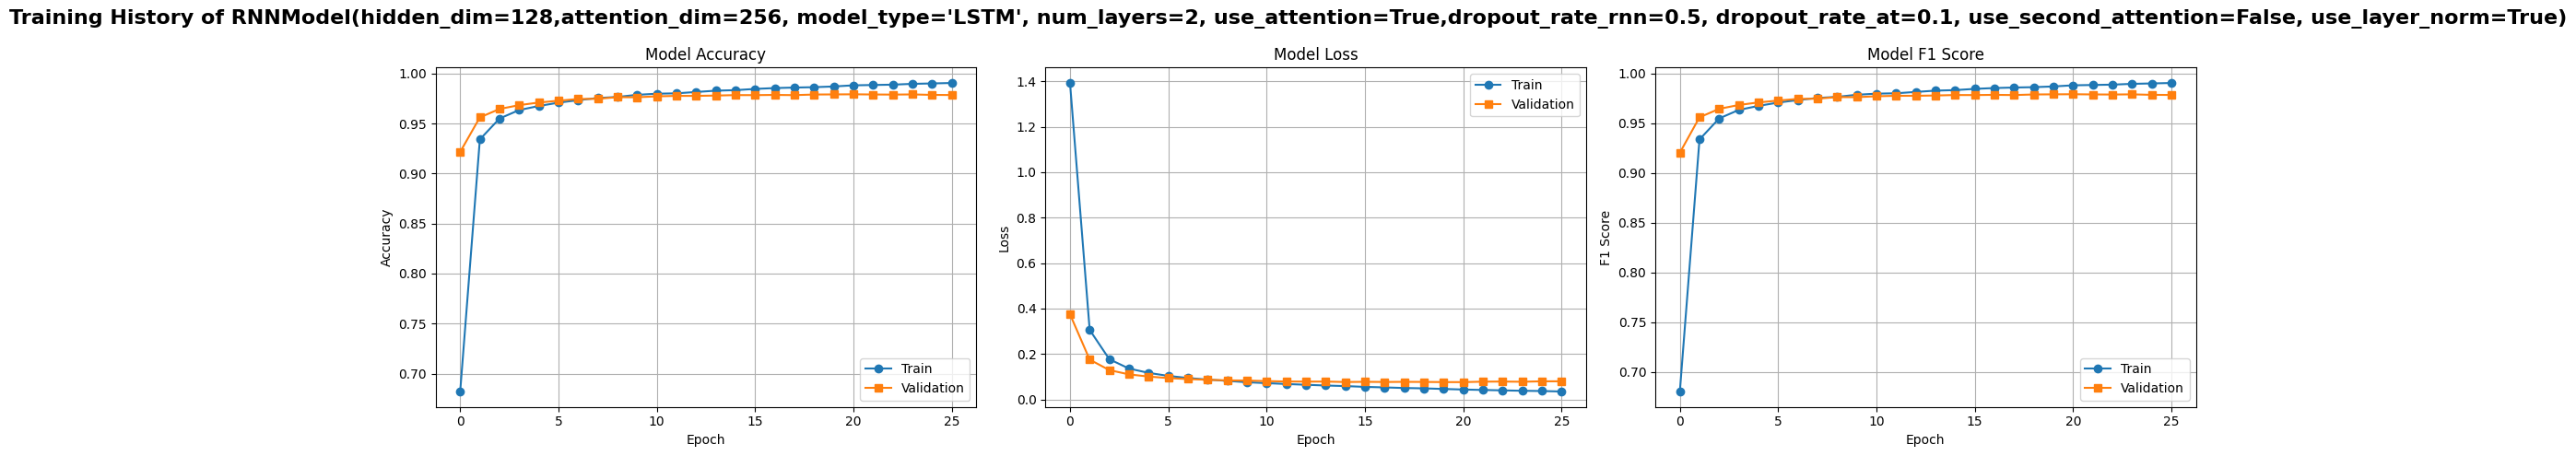

In [26]:
# DataLoaders with collate_fn
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)

epochs = 180
num_classes = len(np.unique(y_train))

model_9 = RNNModel(len(vocab), 300, hidden_dim=128, output_dim=num_classes,attention_dim=256, 
                   model_type='LSTM', num_layers=2, use_attention=True,dropout_rate_rnn=0.5, 
                   dropout_rate_at=0.1, use_second_attention=False, use_layer_norm=True)
model_9 = model_9.float().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_9.parameters(), lr=0.00001)

train_losses_lsatln2, val_losses_lsatln2, train_accuracies_lsatln2, val_accuracies_lsatln2, train_f1s_lsatln2, val_f1s_lsatln2 = train_model(
    model_9, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train_lsatln2, y_pred_train_lsatln2, y_prob_train_lsatln2 = evaluate_model(model_9, train_loader)
y_true_val_lsatln2, y_pred_val_lsatln2, y_prob_val_lsatln2 = evaluate_model(model_9, val_loader) 
y_true_test_lsatln2, y_pred_test_lsatln2, y_prob_test_lsatln2 = evaluate_model(model_9, test_loader)

plot_history(train_losses_lsatln2, val_losses_lsatln2, train_accuracies_lsatln2, val_accuracies_lsatln2, train_f1s_lsatln2, val_f1s_lsatln2, model_name="RNNModel(hidden_dim=128,attention_dim=256, model_type='LSTM', num_layers=2, use_attention=True,dropout_rate_rnn=0.5, dropout_rate_at=0.1, use_second_attention=False, use_layer_norm=True)")

In [59]:
# Train set
metrics(y_true_train_lsatln2, y_pred_train_lsatln2, y_prob_train_lsatln2, "LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5)", "Train")
print()
print()
# Validation Set
metrics(y_true_val_lsatln2, y_pred_val_lsatln2, y_prob_val_lsatln2, "LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5)", "Validation")
print()
print()
# Test set
metrics(y_true_test_lsatln2, y_pred_test_lsatln2, y_prob_test_lsatln2, "LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5)", "Test")

=== LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5) Train ===
---------------------
Macro-averaged scores
Precision score: 0.9901
Recall score: 0.9901
F1 score: 0.9901
AUC score: 0.9960


=== LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5) Validation ===
---------------------
Macro-averaged scores
Precision score: 0.9787
Recall score: 0.9785
F1 score: 0.9786
AUC score: 0.9947


=== LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5) Test ===
---------------------
Macro-averaged scores
Precision score: 0.978
Recall score: 0.9779
F1 score: 0.9779
AUC score: 0.9932


In [58]:
print("Train Set")
macro_pr_auc_train, report1_train, mean_precision_train, mean_recall_train =compute_metrics(y_true_train_lsatln2, y_pred_train_lsatln2, y_prob_train_lsatln2, "LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5)", "Train")
print()
print()
print()
print("Validation Set")
macro_pr_auc_val, report1_val, mean_precision_val, mean_recall_val =compute_metrics(y_true_val_lsatln2, y_pred_val_lsatln2, y_prob_val_lsatln2, "LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5)", "Validation")
print()
print()
print()
print("Test Set")
macro_pr_auc_test, report1_test, mean_precision_test, mean_recall_test =compute_metrics(y_true_test_lsatln2, y_pred_test_lsatln2, y_prob_test_lsatln2, "LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5)", "Test")

Train Set
=== LSTM-Model-9 (128H, 2L, SA-Simple, LN, Dropout=0.5) Train Classification Report ===
              precision    recall  f1-score   support

           0     0.9806    0.9716    0.9761      8026
           1     0.9879    0.9904    0.9892      8009
           2     0.9744    0.9888    0.9816      7971
           3     0.9971    0.9968    0.9970      7930
           4     0.9943    0.9801    0.9872      7959
           5     0.9950    0.9963    0.9956      8018
           6     0.9826    0.9837    0.9832      7992
           7     0.9945    0.9985    0.9965      7951
           8     0.9989    0.9978    0.9983      8046
           9     0.9853    0.9941    0.9897      7975
          10     0.9948    0.9847    0.9897      8040
          11     0.9953    0.9960    0.9956      8017
          12     0.9938    0.9919    0.9928      8046
          13     0.9875    0.9910    0.9892      8020

    accuracy                         0.9901    112000
   macro avg     0.9901    0.9901   

## **5. MLP**

In [27]:
import socket

# Set the default timeout for urllib (default is 60 seconds)
socket.setdefaulttimeout(120)  # Increase the timeout to 120 seconds

word_vectors = api.load("word2vec-google-news-300")

In [28]:
def get_features(X_train_proc, X_val_proc, X_test_proc, representation="tfidf", features_number=5000, reduce_features=False, reduced_features_number=100):
   
    # TF-IDF representation
    if representation == "tfidf":
        vectorizer = TfidfVectorizer(max_features=features_number, sublinear_tf=True)
        X_train = vectorizer.fit_transform([" ".join(x) for x in X_train_proc]).toarray()
        X_val = vectorizer.transform([" ".join(x) for x in X_val_proc]).toarray()
        X_test = vectorizer.transform([" ".join(x) for x in X_test_proc]).toarray()

        if reduce_features:
            assert reduced_features_number is not None
            svd = TruncatedSVD(n_components=reduced_features_number, random_state=42)
            X_train = svd.fit_transform(X_train)
            X_val = svd.transform(X_val)
            X_test = svd.transform(X_test)

    # Word2Vec embeddings representation
    elif representation == "embeddings":
        word_vectors = api.load("word2vec-google-news-300")
        X_train, X_val, X_test = [], [], []

        # Convert text to word embeddings (mean of word vectors)
        for doc in X_train_proc:
            embeddings = [word_vectors[word] for word in doc if word in word_vectors]
            if embeddings:
                centroid = np.mean(embeddings, axis=0)
            else:
                centroid = np.zeros(word_vectors.vector_size)
            X_train.append(centroid)
        X_train = np.array(X_train)

        for doc in X_val_proc:
            embeddings = [word_vectors[word] for word in doc if word in word_vectors]
            if embeddings:
                centroid = np.mean(embeddings, axis=0)
            else:
                centroid = np.zeros(word_vectors.vector_size)
            X_val.append(centroid)
        X_val = np.array(X_val)

        for doc in X_test_proc:
            embeddings = [word_vectors[word] for word in doc if word in word_vectors]
            if embeddings:
                centroid = np.mean(embeddings, axis=0)
            else:
                centroid = np.zeros(word_vectors.vector_size)
            X_test.append(centroid)
        X_test = np.array(X_test)

        if reduce_features:
            assert reduced_features_number is not None
            svd = TruncatedSVD(n_components=reduced_features_number, random_state=42)
            X_train = svd.fit_transform(X_train)
            X_val = svd.transform(X_val)
            X_test = svd.transform(X_test)

    # BoW representation
    else:
        vectorizer = CountVectorizer(max_features=features_number)
        X_train = vectorizer.fit_transform([" ".join(x) for x in X_train_proc]).toarray()
        X_val = vectorizer.transform([" ".join(x) for x in X_val_proc]).toarray()
        X_test = vectorizer.transform([" ".join(x) for x in X_test_proc]).toarray()

        # Dimensionality reduction using TruncatedSVD 
        if reduce_features:
            assert reduced_features_number is not None
            svd = TruncatedSVD(n_components=reduced_features_number, random_state=42)
            X_train = svd.fit_transform(X_train)
            X_val = svd.transform(X_val)
            X_test = svd.transform(X_test)
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


In [29]:
# Define a dictionary for representations
representations = {
    "tfidf": (X_train_proc, X_val_proc, X_test_proc),  
    "word2vec": (X_train_proc, X_val_proc, X_test_proc),
    "bow": (X_train_proc, X_val_proc, X_test_proc)
}

# Parameters for feature extraction
features_number = 2000
reduce_features = True
reduced_features_number = 100

In [30]:
class CustomModel(nn.Module):
    def __init__(self, input_dim, hidden_layers=None,
                 dropout=0.0, batch_norm=False, layer_norm=False,
                 classes_number=20, device=None):
        
        super(CustomModel, self).__init__()
        layers = []
        prev_dim = input_dim

        if hidden_layers:
            for hidden_dim in hidden_layers:
                layers.append(nn.Linear(prev_dim, hidden_dim))
                layers.append(nn.ReLU())
                if batch_norm:
                    layers.append(nn.BatchNorm1d(hidden_dim))
                if layer_norm:
                    layers.append(nn.LayerNorm(hidden_dim))
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, classes_number))
        self.net = nn.Sequential(*layers)

        # Ensure the model is on the correct device
        if device:
            self.to(device)

    def forward(self, x):
        return self.net(x)

- ### **Best MLP Model:**
    - `"word2vec": {
        "MLP with Dropout/Batch/LayerNorm": {
            "hidden_layers": [512], 
            "dropout": 0.5, 
            "batch_norm": True, 
            "layer_norm": True}}`

Training MLP with Dropout/Batch/LayerNorm...
Epoch: 1 / 250 | Training Loss: 1.71244, Validation Loss: 0.88075
Training Accuracy: 0.5123, Validation Accuracy: 0.8413
Training F1: 0.5046, Validation F1: 0.8395
Epoch: 3 / 250 | Training Loss: 0.51996, Validation Loss: 0.37778
Training Accuracy: 0.8639, Validation Accuracy: 0.9015
Training F1: 0.8628, Validation F1: 0.9014
Epoch: 5 / 250 | Training Loss: 0.38375, Validation Loss: 0.30230
Training Accuracy: 0.8878, Validation Accuracy: 0.9106
Training F1: 0.8874, Validation F1: 0.9106
Epoch: 7 / 250 | Training Loss: 0.34176, Validation Loss: 0.27622
Training Accuracy: 0.8960, Validation Accuracy: 0.9156
Training F1: 0.8957, Validation F1: 0.9155
Epoch: 9 / 250 | Training Loss: 0.31889, Validation Loss: 0.26111
Training Accuracy: 0.9009, Validation Accuracy: 0.9188
Training F1: 0.9007, Validation F1: 0.9187
Epoch: 11 / 250 | Training Loss: 0.30726, Validation Loss: 0.25171
Training Accuracy: 0.9038, Validation Accuracy: 0.9210
Training F1: 

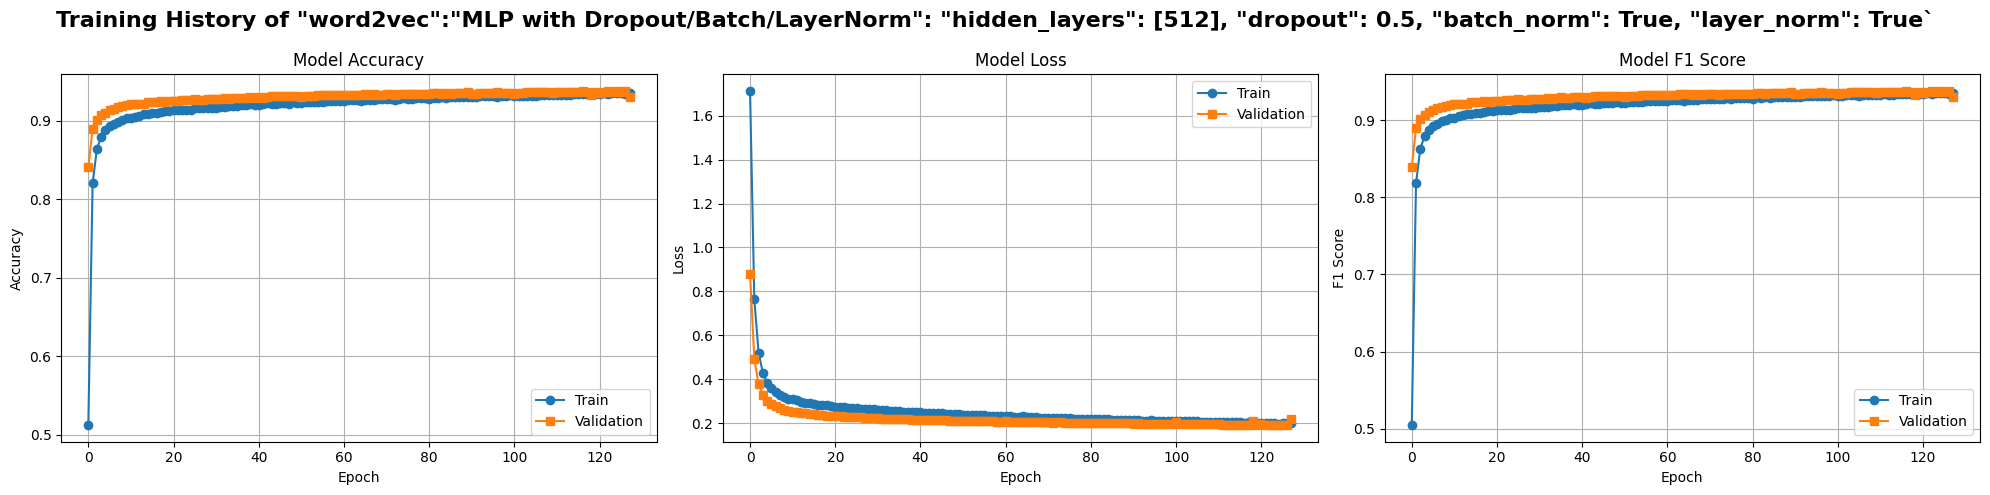

In [32]:
# Define model configurations
representation_model_config = {
    "word2vec": {
        "MLP with Dropout/Batch/LayerNorm": {
            "hidden_layers": [512], 
            "dropout": 0.5, 
            "batch_norm": True, 
            "layer_norm": True
        }
    }
}

# Set parameters
epochs = 250
batch_size = 64 

# Get dataset (assuming `representations` has one key-value pair now)
rep_name, rep_data = list(representations.items())[1]
X_train_proc, X_val_proc, X_test_proc = rep_data  

(X_train_transformed, y_train), (X_val_transformed, y_val), (X_test_transformed, y_test) = get_features(
    X_train_proc, X_val_proc, X_test_proc, rep_name, features_number, reduce_features, reduced_features_number
)

# Create TensorDatasets
train_dataset_mlp = TensorDataset(torch.FloatTensor(X_train_transformed).to(device),
                              torch.LongTensor(y_train).to(device))
val_dataset_mlp = TensorDataset(torch.FloatTensor(X_val_transformed).to(device),
                            torch.LongTensor(y_val).to(device))
test_dataset_mlp = TensorDataset(torch.FloatTensor(X_test_transformed).to(device),
                             torch.LongTensor(y_test).to(device))

# Create DataLoaders
train_loader_mlp = DataLoader(train_dataset_mlp, batch_size=batch_size, shuffle=True)
val_loader_mlp = DataLoader(val_dataset_mlp, batch_size=batch_size)
test_loader_mlp = DataLoader(test_dataset_mlp, batch_size=batch_size)

# Model configuration
model_name, model_config = list(representation_model_config[rep_name].items())[0]  

# Extract model parameters
hidden_layers = model_config["hidden_layers"]
dropout = model_config["dropout"]
batch_norm = model_config["batch_norm"]
layer_norm = model_config["layer_norm"]

# Initialize model
input_dim = X_train_transformed.shape[1]
model_mlp = CustomModel(input_dim, hidden_layers=hidden_layers,
                    dropout=dropout, batch_norm=batch_norm,
                    layer_norm=layer_norm,
                    classes_number=len(np.unique(y_train)),
                    device=device).float()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=0.00001)

# Train model
print(f"Training {model_name}...")
train_losses_mlp, val_losses_mlp, train_accuracies_mlp, val_accuracies_mlp, train_f1s_mlp, val_f1s_mlp = train_model(
    model_mlp, train_loader_mlp, val_loader_mlp, criterion, optimizer, epochs=epochs, patience=5
)

y_true_train_mlp, y_pred_train_mlp, y_prob_train_mlp = evaluate_model(model_mlp, train_loader_mlp)
y_true_val_mlp, y_pred_val_mlp, y_prob_val_mlp = evaluate_model(model_mlp, val_loader_mlp)  # Fixed typo

plot_history(train_losses_mlp, val_losses_mlp, train_accuracies_mlp, val_accuracies_mlp, train_f1s_mlp, val_f1s_mlp, model_name='"word2vec":"MLP with Dropout/Batch/LayerNorm": "hidden_layers": [512], "dropout": 0.5, "batch_norm": True, "layer_norm": True`')

y_test_true_mlp, y_test_pred_mlp, y_test_prob_mlp = evaluate_model(model_mlp, test_loader_mlp)

#### - **The validation loss cannot decrease below 0.19.**

In [66]:
print("Train Set")
macro_pr_auc_trainmlp, report1_trainmlp, mean_precision_trainmlp, mean_recall_trainmlp = compute_metrics(y_true_train_mlp, y_pred_train_mlp, y_prob_train_mlp, "MLP with Dropout/Batch/LayerNorm (512HL, 0.5D, TRUE:BATCH, TRUE:LAYER)", "Train")
print()
print()
print()
print("Validation Set")
macro_pr_auc_valmlp, report1_valmlp, mean_precision_valmlp, mean_recall_valmlp = compute_metrics(y_true_val_mlp, y_pred_val_mlp, y_prob_val_mlp, "MLP with Dropout/Batch/LayerNorm (512HL, 0.5D, TRUE:BATCH, TRUE:LAYER)", "Validation")
print()
print()
print()
print("Test Set")
macro_pr_auc_testmlp, report1_testmlp, mean_precision_testmlp, mean_recall_testmlp = compute_metrics(y_test_true_mlp, y_test_pred_mlp, y_test_prob_mlp, "MLP with Dropout/Batch/LayerNorm (512HL, 0.5D, TRUE:BATCH, TRUE:LAYER)", "Test")

Train Set
=== MLP with Dropout/Batch/LayerNorm (512HL, 0.5D, TRUE:BATCH, TRUE:LAYER) Train Classification Report ===
              precision    recall  f1-score   support

           0     0.9199    0.9173    0.9186      8026
           1     0.9712    0.9808    0.9760      8009
           2     0.9040    0.9077    0.9058      7971
           3     0.9823    0.9709    0.9765      7930
           4     0.9681    0.9621    0.9651      7959
           5     0.9645    0.9681    0.9663      8018
           6     0.9445    0.9442    0.9444      7992
           7     0.9720    0.9789    0.9754      7951
           8     0.9929    0.9924    0.9927      8046
           9     0.8989    0.9297    0.9140      7975
          10     0.9332    0.8882    0.9101      8040
          11     0.9805    0.9839    0.9822      8017
          12     0.9801    0.9718    0.9759      8046
          13     0.9383    0.9535    0.9458      8020

    accuracy                         0.9535    112000
   macro avg     

## **6. Logistic Regression**

- ### **Best Logistic Regression Model:**
    - `tfidf: "LogisticRegression(C=1, max_iter=1000, penalty='l1', solver='saga')`

In [84]:
# Function to extract features
(X_train, y_train), (X_val, y_val), (X_test, y_test) = get_features(
    X_train_proc, X_val_proc, X_test_proc, representation="tfidf", 
    features_number=2000, reduce_features=True, 
    reduced_features_number=100
)

# Define Logistic Regression model and Grid Search parameters
parameters = {
    'solver': ['liblinear', 'saga'],  # solvers to try
    'penalty': ['l1', 'l2'],  # regularization penalties
    'C': [0.01, 0.1, 1],  # inverse of regularization strength
}

logreg = LogisticRegression(max_iter=1000)
grid_search = GridSearchCV(logreg, parameters, cv=3, scoring='accuracy', n_jobs=-1)

# Train model using grid search
grid_search.fit(X_train, y_train)

# Get best model
best_model_tfidf = grid_search.best_estimator_
print(best_model_tfidf)

# Predict on the train set
y_train_pred_tf = best_model_tfidf.predict(X_train)
y_train_pred_proba_tf = best_model_tfidf.predict_proba(X_train)

# Predict on the validation set
y_val_pred_tf = best_model_tfidf.predict(X_val)
y_val_pred_proba_tf = best_model_tfidf.predict_proba(X_val)

# Predict on the test set
y_test_pred_tf = best_model_tfidf.predict(X_test)
y_test_pred_proba_tf = best_model_tfidf.predict_proba(X_test)

# Compute metrics for train set
print("\n=== Train Set Metrics ===")
macro_pr_auc_train, report_train, mean_precision_train, mean_recall_train = compute_metrics(
    y_true=y_train, 
    y_pred=y_train_pred_tf, 
    y_pred_proba=y_train_pred_proba_tf, 
    classifier_name="Logistic Regression (TF-IDF)", 
    dataset_name="Train Set"
)

# Compute metrics for validation set
print("\n=== Validation Set Metrics ===")
macro_pr_auc_val, report_val, mean_precision_val, mean_recall_val = compute_metrics(
    y_true=y_val, 
    y_pred=y_val_pred_tf, 
    y_pred_proba=y_val_pred_proba_tf, 
    classifier_name="Logistic Regression  (TF-IDF)", 
    dataset_name="Validation Set"
)

# Compute metrics for test set
print("\n=== Test Set Metrics ===")
macro_pr_auc_test, report_test, mean_precision_test, mean_recall_test = compute_metrics(
    y_true=y_test, 
    y_pred=y_test_pred_tf, 
    y_pred_proba=y_test_pred_proba_tf, 
    classifier_name="Logistic Regression (TF-IDF)", 
    dataset_name="Test Set"
)

# Extract the macro precision and recall from the report
# Extract macro Precision, Recall, F1-score, and Accuracy for train, test, and validation

macro_precision_train_tfidf = report_train["macro avg"]["precision"]
macro_recall_train_tfidf = report_train["macro avg"]["recall"]
macro_f1_train_tfidf = report_train["macro avg"]["f1-score"]
macro_accuracy_train_tfidf = report_train["accuracy"]

macro_precision_test_tfidf = report_test["macro avg"]["precision"]
macro_recall_test_tfidf = report_test["macro avg"]["recall"]
macro_f1_test_tfidf = report_test["macro avg"]["f1-score"]
macro_accuracy_test_tfidf = report_test["accuracy"]

macro_precision_val_tfidf = report_val["macro avg"]["precision"]
macro_recall_val_tfidf = report_val["macro avg"]["recall"]
macro_f1_val_tfidf = report_val["macro avg"]["f1-score"]
macro_accuracy_val_tfidf = report_val["accuracy"]

LogisticRegression(C=1, max_iter=1000, penalty='l1', solver='saga')

=== Train Set Metrics ===
=== Logistic Regression (TF-IDF) Train Set Classification Report ===
              precision    recall  f1-score   support

           0     0.8740    0.8876    0.8808      8026
           1     0.9659    0.9692    0.9675      8009
           2     0.8864    0.8907    0.8886      7971
           3     0.9765    0.9685    0.9725      7930
           4     0.9563    0.9541    0.9552      7959
           5     0.9454    0.9572    0.9513      8018
           6     0.9153    0.9175    0.9164      7992
           7     0.9627    0.9683    0.9655      7951
           8     0.9924    0.9867    0.9895      8046
           9     0.9119    0.9150    0.9134      7975
          10     0.9310    0.9022    0.9164      8040
          11     0.9730    0.9747    0.9738      8017
          12     0.9667    0.9642    0.9655      8046
          13     0.9248    0.9248    0.9248      8020

    accuracy            

## **7. Majority & Random Classifier**

### **7.1 Majority Classifier**

In [74]:
# Define the majority class classifier
majority_clf = DummyClassifier(strategy='most_frequent')

# Train on the training set
majority_clf.fit(X_train, y_train)

# Predict on train set
y_train_pred_majority = majority_clf.predict(X_train)
y_train_pred_proba_majority = majority_clf.predict_proba(X_train)

# Predict on validation set
y_val_pred_majority = majority_clf.predict(X_val)
y_val_pred_proba_majority = majority_clf.predict_proba(X_val)

# Predict on test set
y_test_pred_majority = majority_clf.predict(X_test)
y_test_pred_proba_majority = majority_clf.predict_proba(X_test)

# Compute and print classification report for train, validation, and test sets
print("\n=== Train Set Classification Report (Majority Classifier) ===")
print(classification_report(y_train, y_train_pred_majority, zero_division=1))

print("\n=== Validation Set Classification Report (Majority Classifier) ===")
print(classification_report(y_val, y_val_pred_majority, zero_division=1))

print("\n=== Test Set Classification Report (Majority Classifier) ===")
print(classification_report(y_test, y_test_pred_majority, zero_division=1))


=== Train Set Classification Report (Majority Classifier) ===
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      8026
           1       1.00      0.00      0.00      8009
           2       1.00      0.00      0.00      7971
           3       1.00      0.00      0.00      7930
           4       1.00      0.00      0.00      7959
           5       1.00      0.00      0.00      8018
           6       1.00      0.00      0.00      7992
           7       1.00      0.00      0.00      7951
           8       0.07      1.00      0.13      8046
           9       1.00      0.00      0.00      7975
          10       1.00      0.00      0.00      8040
          11       1.00      0.00      0.00      8017
          12       1.00      0.00      0.00      8046
          13       1.00      0.00      0.00      8020

    accuracy                           0.07    112000
   macro avg       0.93      0.07      0.01    112000
weighted avg     

In [75]:
y_train_series = pd.Series(y_train)
print(y_train_series.value_counts())

print("Majority class selected by DummyClassifier:", majority_clf.predict([X_test[0]]))

12    8046
8     8046
10    8040
0     8026
13    8020
5     8018
11    8017
1     8009
6     7992
9     7975
2     7971
4     7959
7     7951
3     7930
Name: count, dtype: int64
Majority class selected by DummyClassifier: [8]


### **7.2 Random Classifier**

In [87]:
# Define the random classifier
random_clf = DummyClassifier(strategy='uniform')

# Train on the training set
random_clf.fit(X_train, y_train)

# Predict on train set
y_train_pred_random = random_clf.predict(X_train)
y_train_pred_proba_random = random_clf.predict_proba(X_train)

# Predict on validation set
y_val_pred_random = random_clf.predict(X_val)
y_val_pred_proba_random = random_clf.predict_proba(X_val)

# Predict on test set
y_test_pred_random = random_clf.predict(X_test)
y_test_pred_proba_random = random_clf.predict_proba(X_test)

# Compute metrics for train set
print("\n=== Train Set Metrics (Random Classifier) ===")
macro_pr_auc_train, report_train, mean_precision_train, mean_recall_train = compute_metrics(
    y_true=y_train, 
    y_pred=y_train_pred_random, 
    y_pred_proba=y_train_pred_proba_random, 
    classifier_name="Random Classifier", 
    dataset_name="Train Set"
)

# Compute metrics for validation set
print("\n=== Validation Set Metrics (Random Classifier) ===")
macro_pr_auc_val, report_val, mean_precision_val, mean_recall_val = compute_metrics(
    y_true=y_val, 
    y_pred=y_val_pred_random, 
    y_pred_proba=y_val_pred_proba_random, 
    classifier_name="Random Classifier", 
    dataset_name="Validation Set"
)

# Compute metrics for test set
print("\n=== Test Set Metrics (Random Classifier) ===")
macro_pr_auc_test, report_test, mean_precision_test, mean_recall_test = compute_metrics(
    y_true=y_test, 
    y_pred=y_test_pred_random, 
    y_pred_proba=y_test_pred_proba_random, 
    classifier_name="Random Classifier", 
    dataset_name="Test Set"
)


=== Train Set Metrics (Random Classifier) ===
=== Random Classifier Train Set Classification Report ===
              precision    recall  f1-score   support

           0     0.0728    0.0739    0.0733      8026
           1     0.0734    0.0729    0.0731      8009
           2     0.0696    0.0696    0.0696      7971
           3     0.0677    0.0696    0.0686      7930
           4     0.0723    0.0731    0.0727      7959
           5     0.0708    0.0701    0.0704      8018
           6     0.0715    0.0718    0.0717      7992
           7     0.0684    0.0678    0.0681      7951
           8     0.0770    0.0763    0.0766      8046
           9     0.0725    0.0735    0.0730      7975
          10     0.0726    0.0719    0.0722      8040
          11     0.0708    0.0704    0.0706      8017
          12     0.0704    0.0697    0.0701      8046
          13     0.0690    0.0680    0.0685      8020

    accuracy                         0.0713    112000
   macro avg     0.0713    0.

- If it prints 8, the classifier is choosing the lowest numerical label in case of a tie.
- DummyClassifier is working correctly, but it's picking class 8 due to tie-breaking rules.

---

Below, we can see the macro metrics for the MLP, Logistic Regression, Majority & Random Classifier for test set:

| **Metric**         | **CNN**  | **RNN**  | **MLP**  | **Logistic Regression** | **Majority** | **Random** |
|--------------------|----------|----------|----------|-------------------------|--------------|------------|
| Macro Precision    | 0.9773   | 0.9770   | 0.9379   | 0.9373                  | 0.93         | 0.0731     |
| Macro Recall       | 0.9774   | 0.9770   | 0.9378   | 0.9373                  | 0.07         | 0.0731     |
| Macro F1-score     | 0.9773   | 0.9771   | 0.9378   | 0.9372                  | 0.01         | 0.0731     |
| Macro AUC          | 0.9945   | 0.9938   | 0.9787   | 0.9782                  | -            | 0.5357     |
| Best Val.loss      | 0.07291  | 0.07262  | 0.19186  | -                       | -            | -          |
